In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("listings_villas_appartements.csv")

df.head()

,id,title,url,transaction_type,house_type,city,quartier,price_raw,price_numeric,surface_raw,surface_m2,rooms,bedrooms,bathrooms,features,description,main_image,images_count,scraped_date,property_type
0,8368341,Villa Fairmont Résidences Marrakech,https://www.mubawab.ma/fr/a/8368341/villa-fair...,Vente,Villa,Marrakech,Autre / Centre,Prix à consulter,NaN,340m²,340.0,6 Pièces,4 Chambres,4 Salles de bains,"Jardin, Terrasse, Garage, Vue sur les montagne...",A vendre villa « FAIRMONT Résidences » Front d...,https://www.mubawab-media.com/ad/8/368/341F/h/...,24,2026-09-21,Villa
1,8243313,Terrain Pré autorisé GH2,https://www.mubawab.ma/fr/a/8243313/terrain-pr...,Vente,Villa,Marrakech,Route de l'Ourika,Prix à consulter,NaN,26724m²,26724.0,NaN,NaN,NaN,NaN,Superbe Opportunité d'investissement:Terrain d...,https://www.mubawab-media.com/ad/8/243/313F/h/...,6,2026-09-21,Villa
2,8378297,Villa moderne Route d'Amizmiz,https://www.mubawab.ma/fr/a/8378297/villa-mode...,Vente,Villa,Marrakech,Route d'Amizmiz,Prix à consulter,NaN,NaN,NaN,14 Pièces,9 Chambres,8 Salles de bains,"Terrasse, Piscine, Concierge, Cheminée, Climat...",*** Villa route d'Amizmiz 1200m² *** Route D'A...,https://www.mubawab-media.com/ad/8/378/297F/h/...,33,2026-09-21,Villa
3,8380254,Villa de luxe à vendre à Route de l'Ourika. Su...,https://www.mubawab.ma/fr/a/8380254/villa-de-l...,Vente,Villa,Marrakech,Route de l'Ourika,Prix à consulter,NaN,20000m²,20000.0,9 Pièces,6 Chambres,7 Salles de bains,"Jardin, Terrasse, Garage, Vue sur les montagne...",*Demeure de Prestige à Vendre - Route de l'Our...,https://www.mubawab-media.com/ad/8/380/254F/h/...,1,2026-09-21,Villa
4,8317724,Terrain 1180m en 2 accès différents,https://www.mubawab.ma/fr/a/8317724/terrain-11...,Vente,Villa,Marrakech,Targa,Prix à consulter,NaN,1177m²,1177.0,NaN,NaN,NaN,NaN,"LOT DE VILLA EXCEPTIONNEL À VENDRE – TARGA, MA...",https://www.mubawab-media.com/ad/8/317/724F/h/...,1,2026-09-21,Villa


<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">1- Data Comprehension</h2>
</div>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260 entries, 0 to 2259
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2260 non-null   int64  
 1   title             2260 non-null   object 
 2   url               2260 non-null   object 
 3   transaction_type  2260 non-null   object 
 4   house_type        2260 non-null   object 
 5   city              2260 non-null   object 
 6   quartier          2260 non-null   object 
 7   price_raw         2260 non-null   object 
 8   price_numeric     2212 non-null   float64
 9   surface_raw       2230 non-null   object 
 10  surface_m2        2230 non-null   float64
 11  rooms             2124 non-null   object 
 12  bedrooms          2173 non-null   object 
 13  bathrooms         2166 non-null   object 
 14  features          2088 non-null   object 
 15  description       2260 non-null   object 
 16  main_image        2260 non-null   object 


In [4]:
df.describe()

,id,price_numeric,surface_m2,images_count
count,2.260000e+03,2.212000e+03,2230.000000,2260.000000
mean,8.322372e+06,1.724564e+06,716.721973,16.142920
std,1.529111e+05,3.850779e+06,10900.088899,7.659903
min,6.892492e+06,2.500000e+02,27.000000,1.000000
25%,8.304903e+06,1.200000e+04,80.000000,11.000000
50%,8.378216e+06,4.300000e+04,117.000000,15.000000
75%,8.411603e+06,1.900000e+06,384.000000,21.000000
max,8.420186e+06,5.500000e+07,504870.000000,41.000000


In [5]:
cols_to_drop = ['id','url','house_type', 'features', 'main_image', 'images_count', 'scraped_date']
df = df.drop(columns=cols_to_drop)

print(df.shape)
df.head()

(2260, 13)


,title,transaction_type,city,quartier,price_raw,price_numeric,surface_raw,surface_m2,rooms,bedrooms,bathrooms,description,property_type
0,Villa Fairmont Résidences Marrakech,Vente,Marrakech,Autre / Centre,Prix à consulter,NaN,340m²,340.0,6 Pièces,4 Chambres,4 Salles de bains,A vendre villa « FAIRMONT Résidences » Front d...,Villa
1,Terrain Pré autorisé GH2,Vente,Marrakech,Route de l'Ourika,Prix à consulter,NaN,26724m²,26724.0,NaN,NaN,NaN,Superbe Opportunité d'investissement:Terrain d...,Villa
2,Villa moderne Route d'Amizmiz,Vente,Marrakech,Route d'Amizmiz,Prix à consulter,NaN,NaN,NaN,14 Pièces,9 Chambres,8 Salles de bains,*** Villa route d'Amizmiz 1200m² *** Route D'A...,Villa
3,Villa de luxe à vendre à Route de l'Ourika. Su...,Vente,Marrakech,Route de l'Ourika,Prix à consulter,NaN,20000m²,20000.0,9 Pièces,6 Chambres,7 Salles de bains,*Demeure de Prestige à Vendre - Route de l'Our...,Villa
4,Terrain 1180m en 2 accès différents,Vente,Marrakech,Targa,Prix à consulter,NaN,1177m²,1177.0,NaN,NaN,NaN,"LOT DE VILLA EXCEPTIONNEL À VENDRE – TARGA, MA...",Villa


<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">2- Data Exploration & Cleaning</h2>
</div>

### 1. les valeurs dupliquees

In [6]:
df.duplicated().sum()


np.int64(7)

In [7]:
df.drop_duplicates(inplace=True)

### 2. colonne de transaction

In [8]:
mask_loc = df["title"].str.contains(
    r"\blouer\b|à louer|a louer|location (?:de|longue|saisonni|mensuel|courte)|for rent",
    case=False, na=False, regex=True
)
df.loc[mask_loc, "transaction_type"] = "Location"

df["transaction_type"].value_counts()

transaction_type
Location    1221
Vente       1032
Name: count, dtype: int64

<Axes: title={'center': 'Transaction Type Distribution'}, xlabel='transaction_type'>

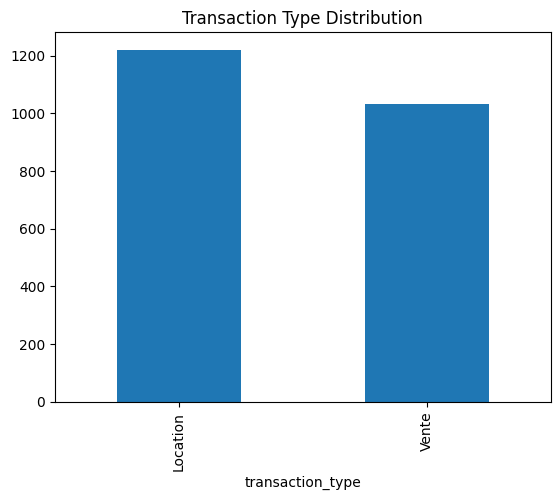

In [9]:
df["transaction_type"].value_counts().plot(kind='bar', title='Transaction Type Distribution')

In [10]:
df = df[df["transaction_type"] == "Vente"].reset_index(drop=True)

print("Après :", df.shape)
df["transaction_type"].value_counts()

Après : (1032, 13)


transaction_type
Vente    1032
Name: count, dtype: int64

### 3. colonne de quartier

In [11]:
df["quartier"].isna().sum()

np.int64(0)

In [12]:
df["quartier"].value_counts()

quartier
Autre / Centre          344
Guéliz                  196
Route de l'Ourika        70
Palmeraie                65
Targa                    63
Route de Tahanaout       45
M'hamid                  28
Route de Casablanca      27
Hivernage                27
Amelkis                  22
Route de Fès             21
Prestigia                21
Agdal                    18
Chrifia                  14
Ménara                   12
Route d'Amizmiz           8
Route de Safi             7
Majorelle                 7
Victor Hugo               7
Semlalia                  6
Mabrouka                  6
Médina                    4
Izdihar                   4
Amerchich                 4
Golf City                 2
Sidi Youssef Ben Ali      1
Tamansourt                1
Bab Doukkala              1
Bab Atlas                 1
Name: count, dtype: int64

<Axes: title={'center': 'Quartier Distribution'}, xlabel='quartier'>

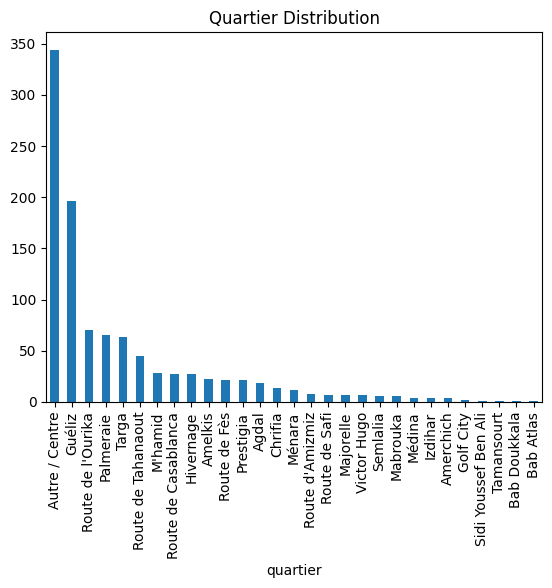

In [13]:
df["quartier"].value_counts().plot(kind='bar', title='Quartier Distribution')

In [14]:
df["quartier"].value_counts().to_string()

"quartier\nAutre / Centre          344\nGuéliz                  196\nRoute de l'Ourika        70\nPalmeraie                65\nTarga                    63\nRoute de Tahanaout       45\nM'hamid                  28\nRoute de Casablanca      27\nHivernage                27\nAmelkis                  22\nRoute de Fès             21\nPrestigia                21\nAgdal                    18\nChrifia                  14\nMénara                   12\nRoute d'Amizmiz           8\nRoute de Safi             7\nMajorelle                 7\nVictor Hugo               7\nSemlalia                  6\nMabrouka                  6\nMédina                    4\nIzdihar                   4\nAmerchich                 4\nGolf City                 2\nSidi Youssef Ben Ali      1\nTamansourt                1\nBab Doukkala              1\nBab Atlas                 1"

#### Regroupement manuel des quartiers rares (proximité géographique)
Les quartiers à faible fréquence sont fusionnés avec un quartier voisin 
géographiquement, sans créer de catégorie "Autre" générique.

In [15]:
mapping_quartiers = {
    "Victor Hugo": "Guéliz",
    "Majorelle": "Guéliz",
    "Semlalia": "Guéliz",
    "Bab Doukkala": "Médina",
    "Bab Atlas": "Médina",
    "Amerchich": "Route de Safi",
    "Izdihar": "Route de Safi",
    "Tamansourt": "Route de Safi",
    "Sidi Youssef Ben Ali": "Route de l'Ourika",
    "Golf City": "Amelkis",
    "Mabrouka": "Route de Fès",
}

df["quartier"] = df["quartier"].replace(mapping_quartiers)

df["quartier"].value_counts()

quartier
Autre / Centre         344
Guéliz                 216
Route de l'Ourika       71
Palmeraie               65
Targa                   63
Route de Tahanaout      45
M'hamid                 28
Hivernage               27
Route de Casablanca     27
Route de Fès            27
Amelkis                 24
Prestigia               21
Agdal                   18
Route de Safi           16
Chrifia                 14
Ménara                  12
Route d'Amizmiz          8
Médina                   6
Name: count, dtype: int64

#### Extraction par correspondance approximative (fuzzy matching)
Pour capturer les variantes ou fautes de frappe des noms de quartiers dans 
title/description, on utilise une comparaison approximative (fuzzy matching) 
au lieu d'une recherche exacte.

In [16]:
# pip install rapidfuzz  (ila ma installich)
from rapidfuzz import fuzz, process
import unicodedata

def normaliser(texte):
    texte = unicodedata.normalize('NFKD', texte).encode('ASCII', 'ignore').decode('utf-8')
    return texte.lower()

quartiers_connus = [
    "Guéliz", "Targa", "Palmeraie", "Hivernage", "M'hamid",
    "Prestigia", "Amelkis", "Agdal", "Chrifia", "Ménara",
    "Route de l'Ourika", "Route de Tahanaout", "Route de Casablanca",
    "Route de Fès", "Route d'Amizmiz", "Route de Safi", "Médina"
]

quartiers_norm = {normaliser(q): q for q in quartiers_connus}
seuil_similarite = 85  # score sur 100, tqder tbeddlo (80-90 gnrlmnt mzyan)

def extraire_quartier_fuzzy(row):
    if row["quartier"] != "Autre / Centre":
        return row["quartier"]
    
    texte = normaliser(f"{row['title']} {row['description']}")
    mots = texte.split()
    
    # nchercho fi chaque n-gram (1-3 mots) l-meilleur match
    for n in [1, 2, 3]:
        for i in range(len(mots) - n + 1):
            segment = " ".join(mots[i:i+n])
            match, score, _ = process.extractOne(
                segment, quartiers_norm.keys(), scorer=fuzz.ratio
            )
            if score >= seuil_similarite:
                return quartiers_norm[match]
    
    return row["quartier"]

df["quartier"] = df.apply(extraire_quartier_fuzzy, axis=1)

print("Avant :", 342)
print("Après :", (df["quartier"] == "Autre / Centre").sum())
df["quartier"].value_counts()

Avant : 342
Après : 226


quartier
Autre / Centre         226
Guéliz                 216
Route de l'Ourika      101
Palmeraie               65
Targa                   64
Route d'Amizmiz         60
Route de Tahanaout      50
Route de Casablanca     45
M'hamid                 34
Route de Fès            33
Hivernage               27
Amelkis                 24
Prestigia               21
Agdal                   18
Route de Safi           16
Chrifia                 14
Ménara                  12
Médina                   6
Name: count, dtype: int64

<Axes: title={'center': 'Quartier Distribution'}, xlabel='quartier'>

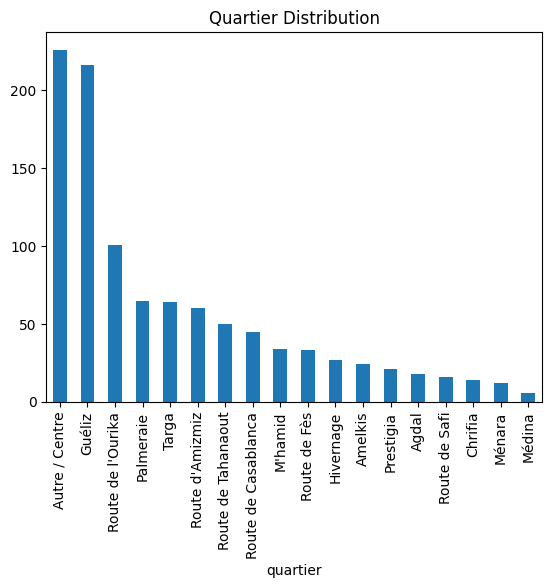

In [17]:
df["quartier"].value_counts().plot(kind='bar', title='Quartier Distribution')

In [18]:
df.head()

,title,transaction_type,city,quartier,price_raw,price_numeric,surface_raw,surface_m2,rooms,bedrooms,bathrooms,description,property_type
0,Villa Fairmont Résidences Marrakech,Vente,Marrakech,Autre / Centre,Prix à consulter,NaN,340m²,340.0,6 Pièces,4 Chambres,4 Salles de bains,A vendre villa « FAIRMONT Résidences » Front d...,Villa
1,Terrain Pré autorisé GH2,Vente,Marrakech,Route de l'Ourika,Prix à consulter,NaN,26724m²,26724.0,NaN,NaN,NaN,Superbe Opportunité d'investissement:Terrain d...,Villa
2,Villa moderne Route d'Amizmiz,Vente,Marrakech,Route d'Amizmiz,Prix à consulter,NaN,NaN,NaN,14 Pièces,9 Chambres,8 Salles de bains,*** Villa route d'Amizmiz 1200m² *** Route D'A...,Villa
3,Villa de luxe à vendre à Route de l'Ourika. Su...,Vente,Marrakech,Route de l'Ourika,Prix à consulter,NaN,20000m²,20000.0,9 Pièces,6 Chambres,7 Salles de bains,*Demeure de Prestige à Vendre - Route de l'Our...,Villa
4,Terrain 1180m en 2 accès différents,Vente,Marrakech,Targa,Prix à consulter,NaN,1177m²,1177.0,NaN,NaN,NaN,"LOT DE VILLA EXCEPTIONNEL À VENDRE – TARGA, MA...",Villa


### 4. colonne de surface

In [19]:
df["surface_raw"].isna().sum()

np.int64(11)

In [20]:
df["surface_m2"].isna().sum()

np.int64(11)

In [21]:
df["surface_m2"].describe()

count      1021.000000
mean       1252.359452
std       16072.988987
min          27.000000
25%          83.000000
50%         227.000000
75%         500.000000
max      504870.000000
Name: surface_m2, dtype: float64

In [22]:
df[['surface_m2']].sort_values('surface_m2').head(20)

,surface_m2
617,27.0
683,34.0
573,36.0
699,36.0
734,39.0
810,40.0
583,40.0
767,40.0
832,40.0
713,40.0


In [23]:
df[['surface_m2']].sort_values('surface_m2', ascending=False).head(20)

,surface_m2
539,504870.0
18,63000.0
382,37500.0
1,26724.0
497,22202.0
3,20000.0
230,19480.0
103,18830.0
555,17000.0
79,12500.0


In [24]:
import re

def extract_surface(text):
    if pd.isna(text):
        return np.nan
    
    text = str(text).lower()
    
    match = re.search(r'(\d+(?:[.,]\d+)?)\s*(?:m²|m2|mètres?\s*carrés?|mètres?)', text)
    
    if match:
        return float(match.group(1).replace(',', '.'))
    
    return np.nan

In [25]:
import re

def extract_surface(text):
    if pd.isna(text):
        return np.nan
    
    text = str(text).lower()
    
    match = re.search(r'(\d+(?:[.,]\d+)?)\s*(?:m²|m2|mètres?\s*carrés?|mètres?)', text)
    
    if match:
        return float(match.group(1).replace(',', '.'))
    
    return np.nan

In [26]:
df['surface_text'] = (
    df['title'].fillna('') + ' ' +
    df['description'].fillna('')
).apply(extract_surface)

In [27]:
df['surface_text'] = (
    df['title'].fillna('') + ' ' +
    df['description'].fillna('')
).apply(extract_surface)

In [28]:
df[['surface_m2', 'surface_text', 'title', 'description']].head(20)

,surface_m2,surface_text,title,description
0,340.0,1452.0,Villa Fairmont Résidences Marrakech,A vendre villa « FAIRMONT Résidences » Front d...
1,26724.0,800.0,Terrain Pré autorisé GH2,Superbe Opportunité d'investissement:Terrain d...
2,NaN,1200.0,Villa moderne Route d'Amizmiz,*** Villa route d'Amizmiz 1200m² *** Route D'A...
3,20000.0,500.0,Villa de luxe à vendre à Route de l'Ourika. Su...,*Demeure de Prestige à Vendre - Route de l'Our...
4,1177.0,180.0,Terrain 1180m en 2 accès différents,"LOT DE VILLA EXCEPTIONNEL À VENDRE – TARGA, MA..."
5,500.0,500.0,Villa 5 suites et piscine avec charme magnifique,Villa de charme 5 chambres avec piscine – Proc...
6,780.0,780.0,Vente ou location Opportunité à saisir villa c...,Découvrez cette magnifique propriété située da...
7,1200.0,NaN,Maison de Maitre A proximité des 3 golfs,Maison de Maitre A proximité des 3 golfs vous ...
8,1000.0,1000.0,Somptueuse villa à vendre à Route de Tahanaout...,Villa de Maître Offrant une vue imprenable sur...
9,424.0,NaN,Villa à vendre front de golf,Villa d’exception avec vue dégagée sur le golf...


In [29]:
nan_surface = df[df['surface_m2'].isna()]

In [30]:
import re
import numpy as np
import pandas as pd


def extract_terrain_surface(title, description):

    text = f"{title if pd.notna(title) else ''} {description if pd.notna(description) else ''}"
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)

    # ==========================================
    # 1. TERRAIN + m²
    # ==========================================

    patterns_m2 = [
        r'(?:superficie|surface)\s+du\s+terrain\s*[:\-]?\s*([\d\s.,]+)\s*m[²2]',

        r'terrain(?:\s+\w+){0,8}?\s*(?:de|d[’\'])?\s*([\d\s.,]+)\s*m[²2]',

        r'terrain[^.]{0,100}?\b([\d\s.,]+)\s*m[²2]'
    ]

    for pattern in patterns_m2:

        match = re.search(pattern, text)

        if match:

            value = match.group(1).strip()
            value = value.replace(' ', '')

            # Exemple : 1.000 / 2.500 / 11.000
            if re.match(r'^\d{1,3}(?:\.\d{3})+$', value):
                value = value.replace('.', '')

            else:
                value = value.replace(',', '.')

            try:
                return float(value)
            except:
                pass


    # ==========================================
    # 2. TERRAIN + HECTARE
    # ==========================================

    patterns_ha = [

        # terrain de 2 hectares
        r'terrain[^.]{0,100}?\b(\d+(?:[.,]\d+)?)\s*(?:hectare|hectares|ha)\b',

        # terrain d'un hectare
        r'terrain[^.]{0,100}?\b(?:un|une|1)\s*(?:hectare|hectares|ha)\b',

        # sur 1 hectare
        r'\bsur\s+(\d+(?:[.,]\d+)?)\s*(?:hectare|hectares|ha)\b',

        # sur un hectare
        r'\bsur\s+(?:un|une)\s*(?:hectare|hectares|ha)\b',

        # 1 hectare dans le texte
        r'\b(\d+(?:[.,]\d+)?)\s*(?:hectare|hectares|ha)\b',

        # un hectare
        r'\b(?:un|une)\s*(?:hectare|hectares|ha)\b'
    ]


    for pattern in patterns_ha:

        match = re.search(pattern, text)

        if match:

            # Cas "un hectare"
            if match.group(0).lower().find('un hectare') != -1 \
               or match.group(0).lower().find('une hectare') != -1:

                return 10000.0

            value = match.group(1)

            try:
                value = float(value.replace(',', '.'))
                return value * 10000
            except:
                pass


    # ==========================================
    # 3. Rien trouvé
    # ==========================================

    return np.nan

In [31]:
df['surface_from_text'] = df.apply(
    lambda row: extract_terrain_surface(
        row['title'],
        row['description']
    ),
    axis=1
)

In [32]:
nan_check = df[
    df['surface_m2'].isna()
][[
    'surface_m2',
    'surface_from_text',
    'title',
    'description'
]]

pd.set_option('display.max_colwidth', 300)

nan_check.head(50)

,surface_m2,surface_from_text,title,description
2,NaN,20000.0,Villa moderne Route d'Amizmiz,"*** Villa route d'Amizmiz 1200m² *** Route D'Amizmiz magnifique villa en parfait état de 1200m² avec un terrain de 2 hectare et une belle piscine. Le bâtiment principal comprend un grand double salon, un grand salon, une salle à manger, une salle de jeux, un salon TV, une chambre principale avec..."
53,NaN,NaN,Somptueuse maison à vendre à Marrakech. 2 belles chambres...,"Nichée dans un environnement naturel préservé, à seulement 20 minutes du centre de Marrakech, cette superbe villa beldi-chic incarne parfaitement l'alliance entre authenticité marocaine et confort contemporain. Offrant une vue panoramique exceptionnelle sur les montagnes de l'Atlas, la propriété..."
64,NaN,738.0,Superbe Villa sur Golf à 10 min du centre ville de Marrakech,"Vaneau Maroc, agence immobilière à Marralech vous propose une superbe villa à vendre sur Golf. La villa se trouve dans une résidence sécurisée à seulement 10 min du centre ville de Marrakech. Cette villa est érigée sur un terrain à taille humaine de 738m2 et développe près de 600m2 habitables su..."
84,NaN,1000.0,Villa contemporaine 5 chambres route de l'Ourika,"L'agence immobilière VANEAU Maroc vous propose à la vente cette superbe villa contemporaine de 437 m² habitables, édifiée sur un magnifique terrain paysager de 1 000 m², offrant un cadre de vie privilégié aux portes de Marrakech. Répartie sur deux niveaux, la propriété dispose de **5 chambres**,..."
96,NaN,NaN,Sompteuse villa nichée au coeur de la Palmeraie,"VANEAU Maroc, vous propose une somptueuse villa nichée au cœur de la palmeraie, d'une superficie habitable de 650m2, composée de 5 suites, chacune dotée de sa propre salle de bains, deux suites sont en rez-de-chaussée, et les trois autres se trouvent à l'étage. Un vaste salon composé d'une parti..."
137,NaN,10000.0,Superbe palais maison d'hote sur 1 hectare,"VANEAU MAROC agence immobilière à Marrakech vous propose cette prestigieuse Maison d'hôte / boutique hôtel qui vous offriras une expérience unique, où l’élégance moderne s’harmonise parfaitement avec la tradition marocaine. Inspirée par le célèbre Patio des Arrayanes de l’Alhambra, cette somptue..."
166,NaN,2500.0,Villa Contemporaine d’Architecte et Domotique Intégrée,"VANEAU MAROC vous propose cette villa neuve, conçue par un architecte pour allier confort moderne et technologie de pointe. Située sur un terrain de 2500 m², cette maison de plain-pied avec sous-sol se distingue par son design épuré, sa fonctionnalité et son intégration technologique avancée, of..."
218,NaN,10000.0,Belle demeure à marrakech à vendre aux allures d'un palais d...,"VANEAU MAROC, agence immbolière de luxe à Marrakech, vous propose cette magnifique demeure aux allures d'un palais des Mille et Une Nuits. Nichée au cœur de Bab Atlas, dans l'extension de la Palmeraie, cette somptueuse résidence de 1650 m² habitables, érigée sur un terrain d'un hectare, vous séd..."
483,NaN,NaN,Villa de Prestige à Vendre,"Villa de Prestige à Vendre – Argan Golf, Marrakech Découvrez cette magnifique villa de prestige sur 3 niveaux, située au cœur du prestigieux domaine Argan Golf, offrant un cadre de vie exclusif, calme et sécurisé, à seulement quelques minutes du centre-ville de Marrakech. Caractéristiques : 6 ch..."
604,NaN,NaN,À vendre: Magnifique appartement 3 chambres au cœur de Guéli...,"Situé en plein centre du quartier vibrant de Guéliz, Vaneau Maroc, votre agence immobilière de luxe, vous présente cet élégant appartement récemment rénové, idéalement situé au 4ème étage d'un immeuble bien entretenu. Ce bien d'exception se compose de 3 chambres lumineuses, de 2 salles de bains ..."


In [33]:
df.loc[
    df['surface_m2'].isna() &
    df['surface_from_text'].notna(),
    'surface_m2'
] = df.loc[
    df['surface_m2'].isna() &
    df['surface_from_text'].notna(),
    'surface_from_text'
]

In [34]:
# Fill only missing surface_m2 values
# when a reliable terrain surface was found in title/description

mask = (
    df['surface_m2'].isna() &
    df['surface_from_text'].notna()
)

df.loc[mask, 'surface_m2'] = df.loc[mask, 'surface_from_text']

print("Number of values filled:", mask.sum())

Number of values filled: 0


In [35]:
print("NaN remaining:", df['surface_m2'].isna().sum())

NaN remaining: 5


In [36]:
df[df['surface_m2'].isna()][
    ['surface_m2', 'surface_from_text', 'title', 'description']
].head(30)

,surface_m2,surface_from_text,title,description
53,NaN,NaN,Somptueuse maison à vendre à Marrakech. 2 belles chambres...,"Nichée dans un environnement naturel préservé, à seulement 20 minutes du centre de Marrakech, cette superbe villa beldi-chic incarne parfaitement l'alliance entre authenticité marocaine et confort contemporain. Offrant une vue panoramique exceptionnelle sur les montagnes de l'Atlas, la propriété..."
96,NaN,NaN,Sompteuse villa nichée au coeur de la Palmeraie,"VANEAU Maroc, vous propose une somptueuse villa nichée au cœur de la palmeraie, d'une superficie habitable de 650m2, composée de 5 suites, chacune dotée de sa propre salle de bains, deux suites sont en rez-de-chaussée, et les trois autres se trouvent à l'étage. Un vaste salon composé d'une parti..."
483,NaN,NaN,Villa de Prestige à Vendre,"Villa de Prestige à Vendre – Argan Golf, Marrakech Découvrez cette magnifique villa de prestige sur 3 niveaux, située au cœur du prestigieux domaine Argan Golf, offrant un cadre de vie exclusif, calme et sécurisé, à seulement quelques minutes du centre-ville de Marrakech. Caractéristiques : 6 ch..."
604,NaN,NaN,À vendre: Magnifique appartement 3 chambres au cœur de Guéli...,"Situé en plein centre du quartier vibrant de Guéliz, Vaneau Maroc, votre agence immobilière de luxe, vous présente cet élégant appartement récemment rénové, idéalement situé au 4ème étage d'un immeuble bien entretenu. Ce bien d'exception se compose de 3 chambres lumineuses, de 2 salles de bains ..."
975,NaN,NaN,Appartement à vendre,"# Appartement de Standing à Vendre – Agdal, Marrakech Offrez-vous un cadre de vie privilégié dans le quartier recherché de l'Agdal, avec ce superbe appartement situé au 1er étage d'une résidence sécurisée, bénéficiant d'une agréable vue sur la piscine. Dès l'entrée, vous serez séduit par ses vol..."


### outliers surface

In [37]:
Q1 = df['surface_m2'].quantile(0.25)
Q3 = df['surface_m2'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

Q1: 83.0
Q3: 500.0
IQR: 417.0
Lower bound: -542.5
Upper bound: 1125.5


In [38]:
outliers = df[
    (df['surface_m2'] < lower) |
    (df['surface_m2'] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 85


In [39]:
outlier_diff = outliers[
    df.loc[outliers.index, 'surface_from_text'].notna() &
    (
        df.loc[outliers.index, 'surface_m2'] !=
        df.loc[outliers.index, 'surface_from_text']
    )
][[
    'surface_m2',
    'surface_from_text',
    'title',
    'description'
]].copy()

outlier_diff = outlier_diff.sort_values('surface_m2')

outlier_diff

,surface_m2,surface_from_text,title,description
128,1155.0,1550.0,Vente Terrain Titré Pour Villa,"Vente d’un terrain titré de 1550 m², idéal pour la construction d’une villa moderne, situé à seulement 13 km de Marrakech, sur la très recherchée Route d’Ourika. Le terrain se trouve au sein d’une résidence privée de 10 villas, offrant un environnement calme et résidentiel. Prix : 1 900 000 DH C..."
7,1200.0,20000.0,Maison de Maitre A proximité des 3 golfs,"Maison de Maitre A proximité des 3 golfs vous propose une superbe villa de maitre dans le triangle d'or de Marrakech, à proximité immédiate d'Al Maaden, d'Amelkis et du Royal Golf. La propriété est érigée sur un terrain d'environ 2 hectares et comprends 8 suites avec salles de bains et dressing...."
552,1450.0,10000.0,Villa de prestige à vendre – Palmeraie,"Villa de prestige à vendre – Palmeraie Située au cœur de la Palmeraie, cette villa d’exception est édifiée sur un terrain d’environ un hectare et bénéficie de volumes rares et d’un cadre privilégié. La propriété développe une importante surface habitable répartie sur sous-sol, rez-de-chaussée et..."
165,1500.0,11000.0,Superbe Villa 15 min du centre ville de Marrakech,Superbe Villa 15 min du centre ville de Marrakech vous propose à l'achat une superbe villa érigée sur un terrain de 11 000m2 à seulement 15 minutes du centre dans le très prisé circuit de la Palmeraie. La villa a été construite avec goût et matériaux nobles alliant architecture Marocaine et le c...
304,1500.0,13000.0,Marrakech I Route de l'Ourika,"Idéalement située sur la Route de l'Ourika, à seulement 25 minutes du centre de Marrakech, cette remarquable villa contemporaine de plain-pied bénéficie d'un environnement d'exception avec une vue panoramique sur les montagnes de l'Atlas. Édifiée sur un terrain paysager d'environ 13.000 m², la p..."
548,1600.0,4000.0,Al maaden golf – propriété signature ultra luxe en première...,"OFF MARKET – VILLA ULTRA LUXE FRONT DE GOLF À AL MAADEN, MARRAKECH Adresse rare au cœur du prestigieux resort Al Maaden, en première ligne de golf, avec une vue panoramique exceptionnelle. Édifiée sur un terrain de 4 000 m², cette villa de prestige offre de très beaux volumes, des prestations ha..."
236,1900.0,17000.0,Maison d'hôte Luxueuse d'architecte à 20 minutes du centre,"Maison d'hôte Luxueuse d'architecte à 20 minutes du centre Vaneau Maroc vous propose une villa luxueuse de 1900m2 habitable, classée 5*****, conçue par un architecte de renom au Maroc, se trouve face à l’Atlas à 20 minutes au sud du centre ville de Marrakech. La propriété comprend au total 10 su..."
551,2000.0,20000.0,À Vendre villa de Prestige sur 2 Hectares,"À saisir rapidement ! Titres Fonciers : 2 - Titre d’un hectare avec villa. - Titre d’un hectare de terrain nu constructible. Emplacement : - Située à 18 km de Marrakech, sur la route de l’Ourika, cette propriété contemporaine d’exception s’étend sur 2 hectares et offre une vue panoramique impren..."
559,3000.0,35000.0,Domaine d'Exception face à l'Atlas,"SANCTUAIRE DE PRESTIGE : FACE À L’ATLAS ​ L'exceptionnel s'installe sur la Route de l’Ourika. Découvrez ce domaine unique de 3,5 hectares, véritable oasis de luxe et de sérénité. ​ - ​3 Villas de Maître aux finitions d'orfèvre - ​12 Suites de luxe avec cheminées privatives - ​3 Piscines à débord..."
525,10000.0,22000.0,Vends 1 hectare,"Je vends un hectare très bien placé, securisé avec accès eau et electricité sur place transformateur 30kva ce qui vous évite les 1 an de démarche à l'ONE et les administrations, sur le bord de la route de Fès, sans piste, accordé pour lotissement SA2, 4villas ou projet touristique ou villa princ..."


In [40]:
df['surface_clean'] = df['surface_m2'].copy()

corrections = {
    6: 20000,
    77: 12500,
    550: 10000,
    549: 20000,
    553: 17000,
    557: 35000,
    93: 11000,
    101: 20000
}

for idx, value in corrections.items():
    df.loc[idx, 'surface_clean'] = value

In [41]:
df.loc[
    corrections.keys(),
    ['surface_m2', 'surface_clean', 'title']
]

,surface_m2,surface_clean,title
6,780.0,20000.0,Vente ou location Opportunité à saisir villa commerciale
77,420.0,12500.0,Villa 10 mn de Marrakech Targa sans vis à vis
550,10000.0,10000.0,Magnifique villa à vendre idéale pr maison d'hôtes
549,1000.0,20000.0,Villa d’Exception Vue sur le Golf AL MAADEN
553,10000.0,17000.0,Grande villa à vendre à la palmeraie
557,350.0,35000.0,Magnifique villa moderne avec jardin et piscine
93,450.0,11000.0,Villa privée sur le Circuit de la Palmeraie
101,1000.0,20000.0,"Terrain 1000 m² idéal villa – face Aqua Park, 18 km Marrakec..."


In [42]:
Q1 = df['surface_clean'].quantile(0.25)
Q3 = df['surface_clean'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

outliers_clean = df[
    (df['surface_clean'] < lower) |
    (df['surface_clean'] > upper)
]

print("Number of outliers:", len(outliers_clean))

Q1: 83.0
Q3: 500.0
IQR: 417.0
Lower bound: -542.5
Upper bound: 1125.5
Number of outliers: 91


In [43]:
pd.set_option('display.max_colwidth', 300)

outliers_clean[
    ['surface_clean', 'title', 'description']
].sort_values('surface_clean')

,surface_clean,title,description
128,1155.0,Vente Terrain Titré Pour Villa,"Vente d’un terrain titré de 1550 m², idéal pour la construction d’une villa moderne, situé à seulement 13 km de Marrakech, sur la très recherchée Route d’Ourika. Le terrain se trouve au sein d’une résidence privée de 10 villas, offrant un environnement calme et résidentiel. Prix : 1 900 000 DH C..."
487,1160.0,Splendide villa isolée à vendre à Hay Targa à Marrakech. Ave...,"Magnifique villa isolée à vendre – Targa Située dans le prestigieux quartier de Targa, cette superbe villa isolée bénéficie d’un environnement calme et résidentiel. Édifiée sur un terrain de 1160 m² avec une superficie habitable d’environ 700 m², elle est répartie sur trois niveaux : cave, rez-d..."
4,1177.0,Terrain 1180m en 2 accès différents,"LOT DE VILLA EXCEPTIONNEL À VENDRE – TARGA, MARRAKECH Emplacement recherché à Targa – Marrakech Superficie : 1 180 m² ️ Un terrain aux possibilités multiples et particulièrement rare Double façade opposée offrant une configuration exceptionnelle avec 2 accès distincts. Plusieurs possibilités de ..."
7,1200.0,Maison de Maitre A proximité des 3 golfs,"Maison de Maitre A proximité des 3 golfs vous propose une superbe villa de maitre dans le triangle d'or de Marrakech, à proximité immédiate d'Al Maaden, d'Amelkis et du Royal Golf. La propriété est érigée sur un terrain d'environ 2 hectares et comprends 8 suites avec salles de bains et dressing...."
303,1200.0,Maison de haut standing à vendre à Route Amizmiz. 3 pièces...,"Prestations de luxe pour cette villa à vendre. Prix 5 000 000 DH. 3 chambres, 4 salles de bains, superficie 1000 m². 3 pièces. Moins de 10 ans. Revêtement: Marbre. Entièrement meublé. Cette belle villa est en vente à Route Amizmiz. Confort et sécurité avec chauffage central et double vitrage. En..."
...,...,...,...
1,26724.0,Terrain Pré autorisé GH2,"Superbe Opportunité d'investissement:Terrain de 2,6 Hectares en Zone GH2, pré-autorisé, pour la construction d'une résidence fermée de villas.Idéalement situé sur la route de l'Ourika au Km 6.Le plan actuel du terrain prévoit 20 Villas en R1 sur des terrains de 800M2La Zone GH2 prévoit la constr..."
557,35000.0,Magnifique villa moderne avec jardin et piscine,"A VENDRE – Superbe Villa Moderne avec Piscine Privée & Jardin Paysager Découvrez cette magnifique villa contemporaine aux prestations haut de gamme, alliant confort moderne, élégance et volumes généreux. Située dans un environnement calme et privilégié, cette propriété offre un cadre de vie exce..."
382,37500.0,"Propriété d’exception 3,75 ha à 16 km de Marrakech","Découvrez cette propriété exceptionnelle entièrement aménagée, située dans un environnement calme et verdoyant, à seulement 16 km de Marrakech. Caractéristiques Superficie du terrain : 37 500 m² Plusieurs villas et bungalows indépendants Piscine Villa principale avec 2 salons Chambres à coucher ..."
18,63000.0,Vente de terrain note pour agricole ou villa par hectare,"Faites une bonne affaire en achetant ce terrain zone agricole et villa par hectare. Superficie 63000 m². Terrain à découvrir à Route de l'Ourika, Marrakech"


### 5. colonne de prix

In [44]:
df[df["price_raw"] == "Prix à consulter"]["price_raw"].value_counts()

price_raw
Prix à consulter    38
Name: count, dtype: int64

In [45]:
import re

def parser_prix(price_raw):
    if price_raw == "Prix à consulter" or pd.isna(price_raw):
        return np.nan
    # delete "DH" (thousand separator), keep numbers
    nombre = re.sub(r"[^\d]", "", price_raw)
    return float(nombre) if nombre else np.nan

df["price_numeric"] = df["price_raw"].apply(parser_prix)

df[["price_raw", "price_numeric"]]

,price_raw,price_numeric
0,Prix à consulter,NaN
1,Prix à consulter,NaN
2,Prix à consulter,NaN
3,Prix à consulter,NaN
4,Prix à consulter,NaN
...,...,...
1027,4 330 000 DH,4330000.0
1028,4 900 000 DH,4900000.0
1029,5 000 000 DH,5000000.0
1030,5 800 000 DH,5800000.0


In [46]:
df.loc[22:36, ["price_raw", "price_numeric"]]

,price_raw,price_numeric
22,26 000 DH,26000.0
23,35 000 DH,35000.0
24,42 000 DH,42000.0
25,50 000 DH,50000.0
26,140 000 DH,140000.0
27,250 000 DH,250000.0
28,260 000 DH,260000.0
29,290 000 DH,290000.0
30,310 000 DH,310000.0
31,320 000 DH,320000.0


In [47]:
df["price_numeric"].describe()

count    9.940000e+02
mean     3.793580e+06
std      5.014107e+06
min      1.100000e+04
25%      1.200000e+06
50%      2.200000e+06
75%      4.850000e+06
max      5.500000e+07
Name: price_numeric, dtype: float64

In [48]:
Q1 = df['price_numeric'].quantile(0.25)
Q3 = df['price_numeric'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)

Q1: 1200000.0
Q3: 4850000.0
IQR: 3650000.0
Lower: -4275000.0
Upper: 10325000.0


In [49]:
price_outliers = df[
    (df['price_numeric'] < lower) |
    (df['price_numeric'] > upper)
]

print("Number of price outliers:", len(price_outliers))

Number of price outliers: 47


### 6.  colonnes de rooms , bedrooms , bathrooms 


In [50]:
df["rooms"].isna().sum()

np.int64(127)

In [51]:
df["rooms"].unique()

array(['6 Pièces', nan, '14 Pièces', '9 Pièces', '8 Pièces', '1 Pièce',
       '10 Pièces', '15 Pièces', '5 Pièces', '7 Pièces', '3 Pièces',
       '4 Pièces', '11 Pièces', '12 Pièces', '18 Pièces', '2 Pièces',
       '20 Pièces', '21 Pièces', '13 Pièces', '16 Pièces'], dtype=object)

In [52]:
df["rooms"].value_counts()

rooms
3 Pièces     202
5 Pièces     130
4 Pièces     121
2 Pièces     104
6 Pièces     102
7 Pièces      75
8 Pièces      47
1 Pièce       37
9 Pièces      33
10 Pièces     17
12 Pièces      8
14 Pièces      6
11 Pièces      6
15 Pièces      5
18 Pièces      3
21 Pièces      3
13 Pièces      3
16 Pièces      2
20 Pièces      1
Name: count, dtype: int64

In [53]:
df["rooms"] = df["rooms"].str.extract(r"(\d+)").astype(float)

df["rooms"].describe()

count    905.000000
mean       4.965746
std        2.930224
min        1.000000
25%        3.000000
50%        4.000000
75%        6.000000
max       21.000000
Name: rooms, dtype: float64

In [54]:
df[df["rooms"] > 15][["title", "rooms", "bedrooms", "bathrooms", "surface_m2", "property_type","price_numeric"]].sort_values("rooms", ascending=False)

,title,rooms,bedrooms,bathrooms,surface_m2,property_type,price_numeric
520,Ensemble residentiel klm 10 route de ourzazate,21.0,11 Chambres,8 Salles de bains,940.0,Villa,12000000.0
543,Deux villas à vendre VNA route d’amizmiz,21.0,5 Chambres,5 Salles de bains,10005.0,Villa,18500000.0
350,Villa avec piscine à Marrakech,21.0,14 Chambres,15 Salles de bains,800.0,Villa,5200000.0
236,Maison d'hôte Luxueuse d'architecte à 20 minutes du centre,20.0,10 Chambres,NaN,1900.0,Villa,3950000.0
82,"Amelkis 1: Villa neuve à vendre en 5 Chs, Piscine",18.0,5 Chambres,5 Salles de bains,320.0,Villa,1050000.0
89,Vente villa d'hôte a 18km route casablanca,18.0,14 Chambres,14 Salles de bains,900.0,Villa,1200000.0
530,Vente maison d’hôtes de prestige à Marrakech. Meublée,18.0,14 Chambres,14 Salles de bains,1280.0,Villa,14000000.0
528,Villa de maître à vendre,16.0,6 Chambres,6 Salles de bains,850.0,Villa,14000000.0
555,"Villa Haute Standing 1,7 Hects. À Vendre R. Ourika",16.0,11 Chambres,12 Salles de bains,17000.0,Villa,39500000.0


In [55]:
df["bedrooms"].isna().sum()

np.int64(81)

In [56]:
df["bedrooms"] = df["bedrooms"].str.extract(r"(\d+)").astype(float)

df["bedrooms"].describe()

count    951.000000
mean       3.282860
std        1.791474
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       14.000000
Name: bedrooms, dtype: float64

In [57]:
df["bathrooms"].isna().sum()

np.int64(91)

In [58]:
df["bathrooms"] = df["bathrooms"].str.extract(r"(\d+)").astype(float)

df["bathrooms"].describe()

count    941.000000
mean       2.917109
std        1.954682
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: bathrooms, dtype: float64

In [59]:
# check des lignes li l-extraction 9raت (mn description, machi mn colonne originale)
df[["title", "description", "bedrooms", "bathrooms"]].sample(10)

,title,description,bedrooms,bathrooms
176,Magnifique villa plain pied avec piscine sur résidence,"Nous mettons à la vente une magnifique villa plain-pied d’une superficie totale de 700 M2 et 190M2 habitable, située au sein d’une belle résidence calme et sécurisée, composée exclusivement de villas plain-pied, garantissant une parfaite intimité et l’absence de vis-à-vis, sur la route de Fès. L...",3.0,3.0
921,Appartement en vente à Route de Tahanaout. 2 chambres. Meu...,"Découvrez cet appartement à vendre. Prix 1 950 000 DH. 2 chambres, 2 salles de bains, 80 m². 5 pièces lumineuses. Bon état / habitable. Meublé. Cet appartement est proposé à la vente à Route de Tahanaout. En plus d'une terrasse, dispose également d'un jardin et d'un parking. Confort et sécurité ...",2.0,2.0
738,"Green View Resort: 46 m², 1 chambre, aux portes de la Palmer...","GREEN VIEW RESORT, aux portes de la Palmeraie, Marrakech. Appartement de 46 m², 1 chambre, 1 salle de bains, 2 pièces, avec place de parking. Prix : 1 104 000 DH, soit 24 000 DH le m². Plan de paiement : 50 % à la réservation, 25 % à la fin du gros œuvre, 25 % à la remise des clés. Fonds sécuris...",1.0,1.0
680,Vend appartement à Ain mezouar gueliz. 1 chambre,"RITAJ RESIDENCE – Votre nouveau chez-vous au cœur de Marrakech Appartements à partir de 700 000 DH – Livraison prévue début 2027 Offrez-vous un cadre de vie unique à seulement 5 minutes de la gare de Marrakech, de Guéliz et du boulevard Mohamed VI. RITAJ RESIDENCE est une résidence fermée, moder...",1.0,1.0
558,Somptueuse maison à vendre. 7 chambres agréables. Meublé,"VILLA D’EXCEPTION OFF MARKET – 7 SUITES – 6 600 M² DE TERRAIN – 1 000 M² BÂTIS – MARRAKECH Dans un environnement privilégié et parfaitement préservé à Marrakech, cette propriété d’exception est édifiée sur un superbe terrain de 6 600 m², magnifiquement arboré de très beaux arbres matures et offr...",7.0,8.0
483,Villa de Prestige à Vendre,"Villa de Prestige à Vendre – Argan Golf, Marrakech Découvrez cette magnifique villa de prestige sur 3 niveaux, située au cœur du prestigieux domaine Argan Golf, offrant un cadre de vie exclusif, calme et sécurisé, à seulement quelques minutes du centre-ville de Marrakech. Caractéristiques : 6 ch...",6.0,1.0
270,Belles villa à Marrakech,"Très belle villa à vendre combinant luxe et confort. Prix 4 450 000 DH. 8 pièces, 4 salles de bains, 357 m². 4 chambres à coucher. Moins de 5 ans. Type de sol: Carrelage. Confort et tradition avec un beau salon marocain. Le bien dispose également d'une antenne parabolique et le carter sécurisée....",4.0,4.0
1007,Magnifique appart Prestigia,"Marrakech Essentiel Immobilier vous propose ce magnifique appartement à la vente. L'appartement fait 108 m2 3 chambres 2 salles de bain Salon Coin salle à manger Cuisine terrasse Cheminée L'appartement a était entièrement rénové avec goût. Prix 2 800 000 DH Honoraires d'agence 2,5%HT Nous contac...",3.0,2.0
122,Terrain viabilisé VNA 520m2 a 1330m2,"Nouveau projet résidentiel – Terrains & Villas sur mesure Découvrez Olivia Gardens, un nouveau domaine résidentiel situé dans un environnement calme et verdoyant à seulement 20 minutes du centre de Marrakech. Ce projet unique de plus de 5 hectares propose 61 lots de terrains pour villas R+1 au c...",NaN,NaN
377,Villa contemporaine à vendre – route d’ Amizmiz km 5,"VILLA CONTEMPORAINE À VENDRE – ROUTE D AMIZMIZ KM 5 À vendre, magnifique villa contemporaine située sur la Route d’ Amizmiz, à environ 5 km de Marrakech, au sein d’un lotissement privé composé de seulement 18 villas. Implantée sur un terrain de 1 050 m², la villa développe une surface habitable ...",4.0,5.0


In [60]:
import re
import unicodedata

def normaliser(texte):
    texte = unicodedata.normalize('NFKD', texte).encode('ASCII', 'ignore').decode('utf-8')
    return texte.lower()

# dict: {colonne: liste de patterns regex (mot-clé après le nombre)}
patterns = {
    "rooms":     r"(\d+)\s*(?:pieces?|rooms?)\b",
    "bedrooms":  r"(\d+)\s*(?:chambres?|bedrooms?|chbr|ch\.)\b",
    "bathrooms": r"(\d+)\s*(?:salles?\s*de\s*bains?|sdb|bathrooms?)\b",
}

def extraire_toutes(row):
    texte = normaliser(f"{row['title']} {row['description']}")
    resultats = {}
    for col, pattern in patterns.items():
        if pd.notna(row[col]):
            resultats[col] = row[col]
        else:
            match = re.search(pattern, texte)
            resultats[col] = float(match.group(1)) if match else np.nan
    return pd.Series(resultats)

df[["rooms", "bedrooms", "bathrooms"]] = df.apply(extraire_toutes, axis=1)

print("rooms NaN :", df["rooms"].isna().sum())
print("bedrooms NaN :", df["bedrooms"].isna().sum())
print("bathrooms NaN :", df["bathrooms"].isna().sum())

rooms NaN : 127
bedrooms NaN : 79
bathrooms NaN : 85


### detection des outliers

In [61]:
def detecter_outliers_iqr(df, colonne):
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    outliers = df[(df[colonne] < borne_inf) | (df[colonne] > borne_sup)]
    print(f"{colonne}: {len(outliers)} outliers (bornes: [{borne_inf:.0f}, {borne_sup:.0f}])")
    return outliers

for col in ["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]:
    detecter_outliers_iqr(df, col)

price_numeric: 47 outliers (bornes: [-4275000, 10325000])
surface_m2: 85 outliers (bornes: [-542, 1126])
rooms: 37 outliers (bornes: [-2, 10])
bedrooms: 23 outliers (bornes: [-1, 7])
bathrooms: 10 outliers (bornes: [-4, 8])


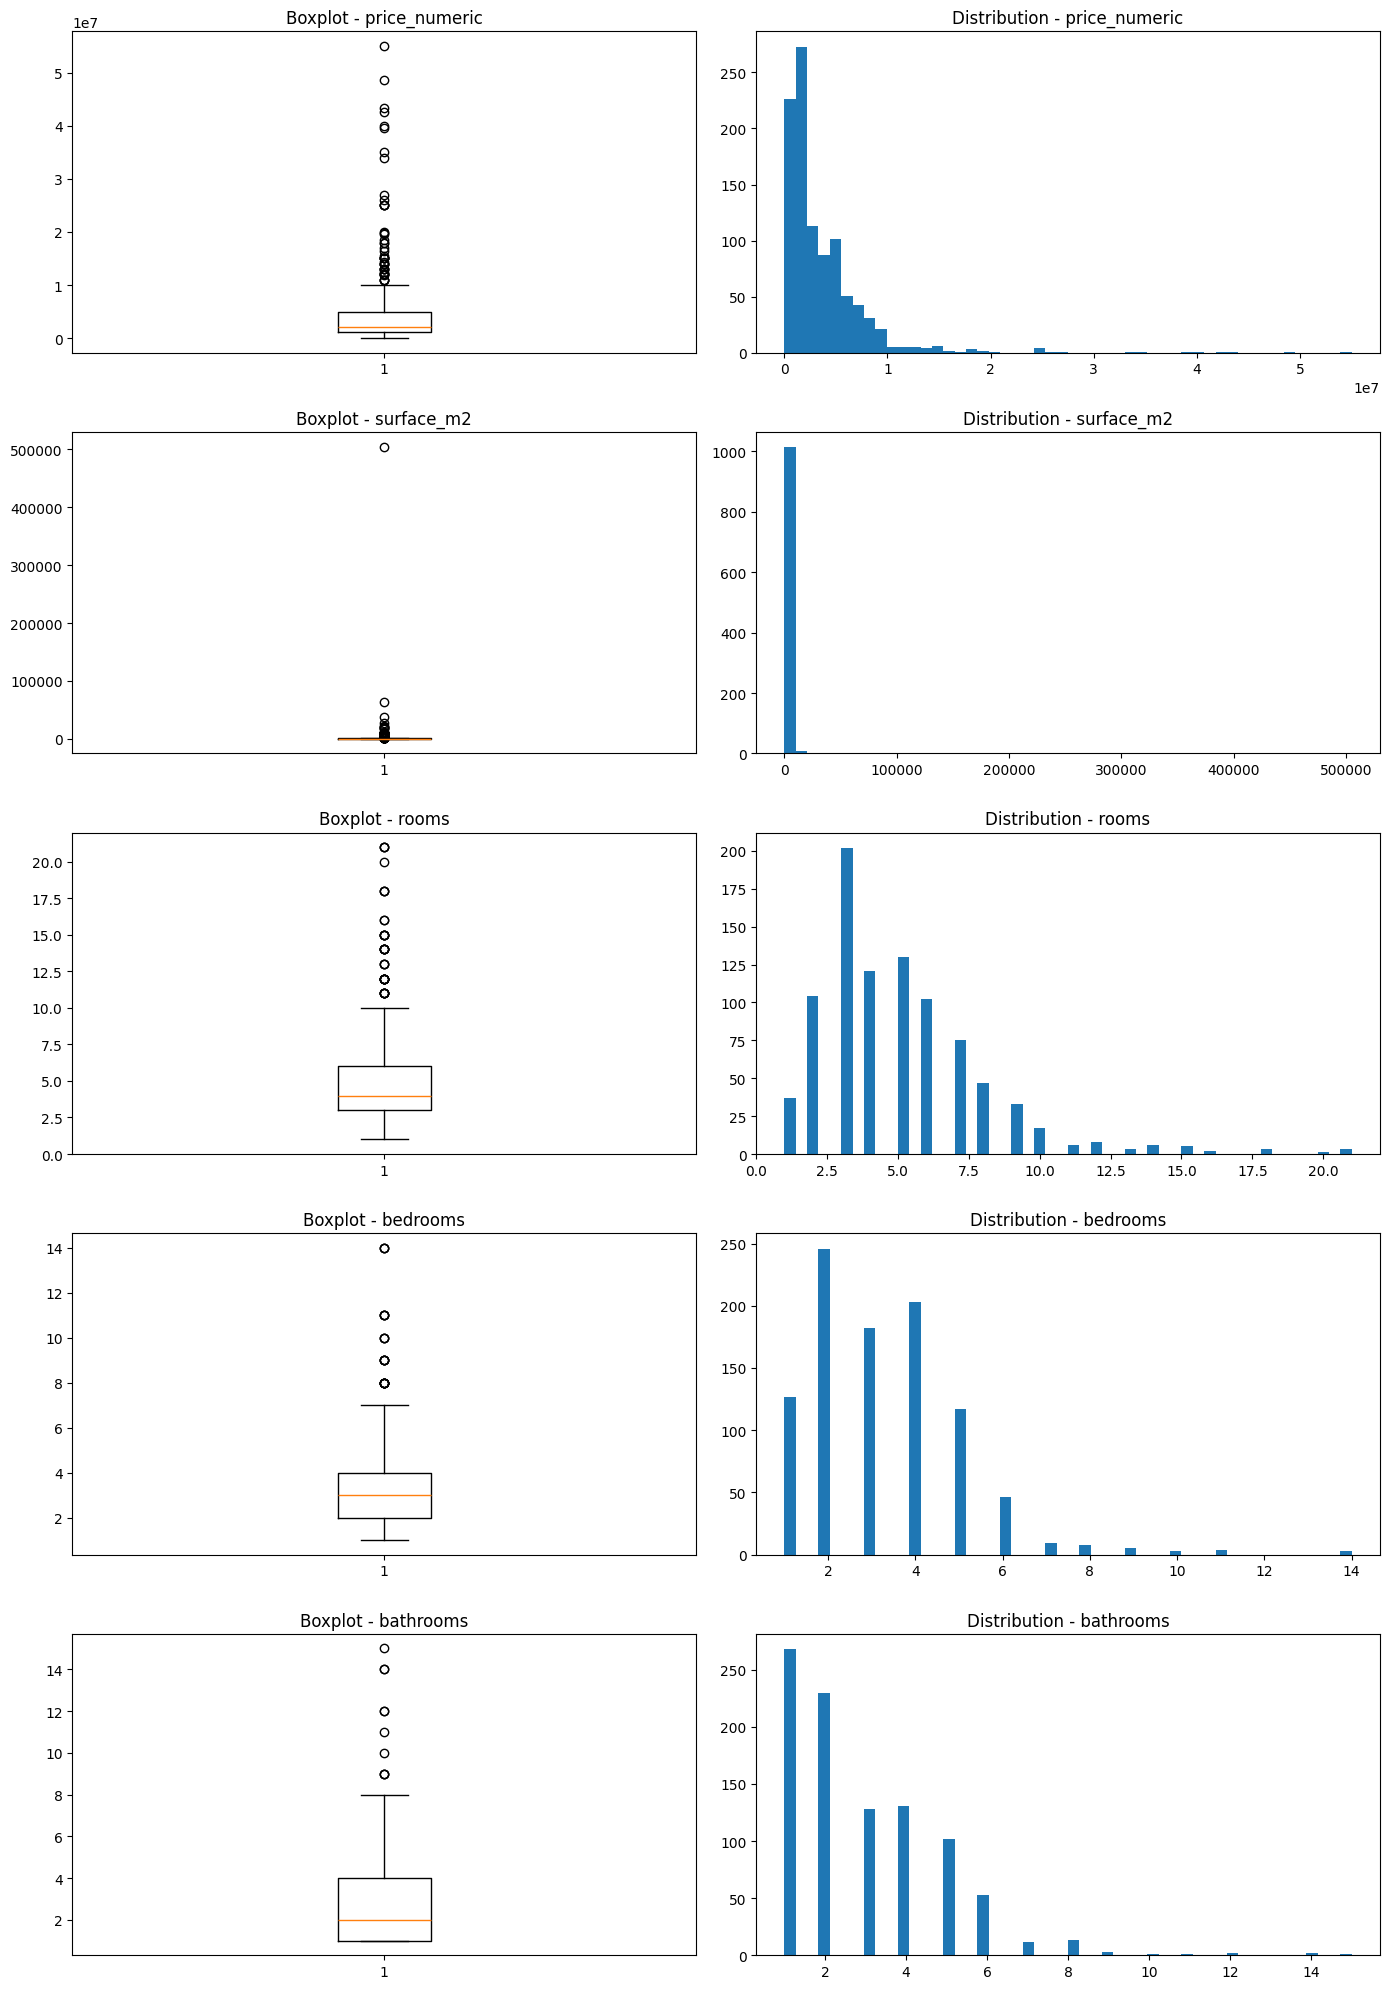

In [62]:
import matplotlib.pyplot as plt

cols = ["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]

fig, axes = plt.subplots(len(cols), 2, figsize=(14, 4*len(cols)))

for i, col in enumerate(cols):
    # Boxplot
    axes[i, 0].boxplot(df[col].dropna())
    axes[i, 0].set_title(f"Boxplot - {col}")
    
    # Histogram
    axes[i, 1].hist(df[col].dropna(), bins=50)
    axes[i, 1].set_title(f"Distribution - {col}")

plt.tight_layout()
plt.show()

In [63]:
for col in ["rooms", "bedrooms", "bathrooms"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index())
    print()

--- rooms ---
rooms
1.0      37
2.0     104
3.0     202
4.0     121
5.0     130
6.0     102
7.0      75
8.0      47
9.0      33
10.0     17
11.0      6
12.0      8
13.0      3
14.0      6
15.0      5
16.0      2
18.0      3
20.0      1
21.0      3
Name: count, dtype: int64

--- bedrooms ---
bedrooms
1.0     127
2.0     246
3.0     182
4.0     203
5.0     117
6.0      46
7.0       9
8.0       8
9.0       5
10.0      3
11.0      4
14.0      3
Name: count, dtype: int64

--- bathrooms ---
bathrooms
1.0     268
2.0     230
3.0     128
4.0     131
5.0     102
6.0      53
7.0      12
8.0      13
9.0       3
10.0      1
11.0      1
12.0      2
14.0      2
15.0      1
Name: count, dtype: int64



In [64]:
# On garde rooms/bedrooms/bathrooms NUMERIQUES (pas de pd.cut => pas de perte d'information)
# On plafonne juste les valeurs extremes
for col, cap in [("rooms", 15), ("bedrooms", 12), ("bathrooms", 12)]:
    df[col] = df[col].clip(upper=cap)

df[["rooms", "bedrooms", "bathrooms"]].describe()

,rooms,bedrooms,bathrooms
count,905.000000,953.000000,947.000000
mean,4.928177,3.273872,2.914467
std,2.766010,1.756596,1.910821
min,1.000000,1.000000,1.000000
25%,3.000000,2.000000,1.000000
50%,4.000000,3.000000,2.000000
75%,6.000000,4.000000,4.000000
max,15.000000,12.000000,12.000000


In [65]:
print(df[["rooms", "bedrooms", "bathrooms"]].isna().sum())

rooms        127
bedrooms      79
bathrooms     85
dtype: int64


In [66]:
# AUCUNE suppression : les annonces sans prix ("Prix à consulter") restent dans df.
# Elles ne servent pas a l'entrainement (pas de label) mais on leur PREDIT un prix a la fin.
print("Annonces avec prix    :", df["price_numeric"].notna().sum())
print("Annonces sans prix    :", df["price_numeric"].isna().sum())
print(df.shape)

Annonces avec prix    : 994
Annonces sans prix    : 38
(1032, 16)


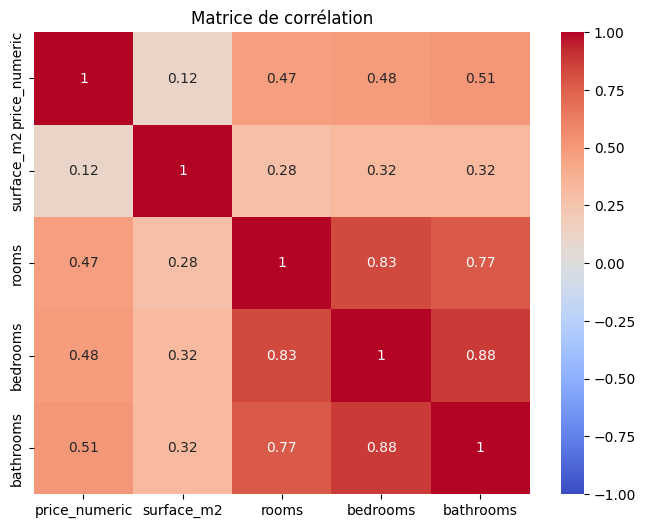

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
cols_numeriques = ["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_numeriques].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()

In [68]:
# Correlation avec log(surface) bach n-testiw wach l-problem houwa l-outliers
df["log_surface"] = np.log1p(df["surface_m2"])
df["log_price"] = np.log1p(df["price_numeric"])

print(df[["log_price", "log_surface"]].corr())

             log_price  log_surface
log_price     1.000000     0.525836
log_surface   0.525836     1.000000


<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">3- Preprocessing</h2>
</div>

### features engineering

In [69]:
df[df["description"].str.contains("neuf|rénové|renove|ancien|état|construit en|ans", case=False, na=False)][["title", "description"]].head(10)

,title,description
2,Villa moderne Route d'Amizmiz,"*** Villa route d'Amizmiz 1200m² *** Route D'Amizmiz magnifique villa en parfait état de 1200m² avec un terrain de 2 hectare et une belle piscine. Le bâtiment principal comprend un grand double salon, un grand salon, une salle à manger, une salle de jeux, un salon TV, une chambre principale avec..."
5,Villa 5 suites et piscine avec charme magnifique,"Villa de charme 5 chambres avec piscine – Proche Oberoi Dans un environnement calme et verdoyant, à proximité de The Oberoi Marrakech, découvrez cette villa de caractère d’environ 500 m², édifiée sur un magnifique terrain arboré de 1 hectare. Entièrement de plain-pied, elle offre 5 chambres avec..."
6,Vente ou location Opportunité à saisir villa commerciale,"Découvrez cette magnifique propriété située dans le quartier prisé de Guéliz, à Marrakech. Avec une vaste surface construite de 780 m² s'étendant sur un terrain de 480 m², cette maison spacieuse offre un cadre de vie idéal en plein cœur de la ville. Son emplacement à Guéliz est stratégique, à pr..."
7,Maison de Maitre A proximité des 3 golfs,"Maison de Maitre A proximité des 3 golfs vous propose une superbe villa de maitre dans le triangle d'or de Marrakech, à proximité immédiate d'Al Maaden, d'Amelkis et du Royal Golf. La propriété est érigée sur un terrain d'environ 2 hectares et comprends 8 suites avec salles de bains et dressing...."
10,Villa de haut standing à vendre à Route de Tahanaout. Surfac...,"Les Jardins Blancs allient modernité architecturale et sérénité résidentielle dans un emplacement d’exception à Marrakech. Composée de 23 villas aux lignes épurées, la résidence se distingue par sa situation privilégiée à proximité immédiate de l’Argan Golf, un atout majeur pour la valorisation ..."
11,Splendide villa à vendre à Route de l'Ourika. Maison d hôtes,"Propriété d’Exception à Marrakech – Deux Villas de Charme sur 18.500 m² Titrés Située à Sidi Abdellah Ghiat, dans un environnement paisible et verdoyant à quelques minutes de Marrakech, cette magnifique propriété offre un cadre de vie rare, alliant élégance, confort et nature. Implantée sur un t..."
12,Magnifique villa à vendre à Route de Tahanaout. Surface de 1...,"Les Jardins Blancs allient modernité architecturale et sérénité résidentielle dans un emplacement d’exception à Marrakech. Composée de 23 villas aux lignes épurées, la résidence se distingue par sa situation privilégiée à proximité immédiate de l’Argan Golf, un atout majeur pour la valorisation ..."
13,Marrakech I Palmeraie,"Située dans l'un des secteurs les plus recherchés de la Palmeraie, cette propriété développe près de 1 000 m² habitables au cœur d'un domaine paysager d'un hectare. Elle se distingue par ses volumes généreux, sa luminosité et ses espaces de réception largement ouverts sur les jardins, les terras..."
15,Somptueuse maison à vendre à Route de Tahanaout. Surface de...,"Les Jardins Blancs allient modernité architecturale et sérénité résidentielle dans un emplacement d’exception à Marrakech. Composée de 23 villas aux lignes épurées, la résidence se distingue par sa situation privilégiée à proximité immédiate de l’Argan Golf, un atout majeur pour la valorisation ..."
16,Vente villa de luxe à Route de Tahanaout. 3 belles chambres,"Les Jardins Blancs allient modernité architecturale et sérénité résidentielle dans un emplacement d’exception à Marrakech. Composée de 23 villas aux lignes épurées, la résidence se distingue par sa situation privilégiée à proximité immédiate de l’Argan Golf, un atout majeur pour la valorisation ..."


In [70]:
mots_etat = ["neuf", "rénové", "renove", "à rénover", "a renover", "bon état", "excellent état", "refait à neuf", "vna", "titré"]

for mot in mots_etat:
    count = df["description"].str.contains(mot, case=False, na=False).sum()
    print(f"{mot}: {count}")

neuf: 44
rénové: 28
renove: 0
à rénover: 2
a renover: 0
bon état: 8
excellent état: 4
refait à neuf: 3
vna: 7
titré: 72


In [71]:
pd.set_option('display.max_colwidth', None)
exemples = df[df["description"].str.contains("construit en|ans d'ancienneté|année de construction", case=False, na=False)][["title", "description"]].head(5)
for idx, row in exemples.iterrows():
    print(row["title"])
    print(row["description"])
    print("---")

Villa d’exception sur golf
Sur 780 m2 et 650 de jouissance de terrain Piscine pierre de Bali Douche ext a débordement Terrasse Année de construction fin 2025 Arboré 550 m2 Alu du Maroc menuiseries double vitrage Douche ext Non mitoyenne Barbecue Puit Place de parking 1 Au RDC Lave main a l’entrée avec WC 3 salons Salle a manger Petit jardinet intérieur Niches de décoration Rideaux électrique Cuisine entièrement aménagée et équipée Laminâmes pour plan d...
---
Vend appartement à Guéliz. Surface de 84 m². Jardin et asc...
Situé dans le quartier prisé de Guéliz à Marrakech, cet appartement moderne de 84 m² offre un cadre de vie élégant et confortable. Avec une construction relativement récente, entre 1 et 5 ans d'ancienneté, il se trouve au deuxième étage d'un immeuble équipé d'un ascenseur, garantissant un accès facile et sécurisé. L'intérieur de l'appartement est caractérisé par un sol en carrelage qui confère une atmosphère fraîche et contemporaine aux espaces...
---


In [72]:
mots_age = ["construit en", "année de construction", "ans d'ancienneté", "bâti en", "date de construction", "ans", "neuf de"]

for mot in mots_age:
    count = df["description"].str.contains(mot, case=False, na=False).sum()
    print(f"{mot}: {count}")

construit en: 0
année de construction: 1
ans d'ancienneté: 1
bâti en: 0
date de construction: 0
ans: 541
neuf de: 14


#### Extraction de l'état du bien
On classe chaque annonce selon des mots-clés trouvés dans title/description :
neuf, rénové, bon état, excellent état, à rénover (VNA).

In [73]:
import re

def extraire_etat(row):
    texte = f"{row['title']} {row['description']}".lower()
    
    if re.search(r"à rénover|a renover|vna\b", texte):
        return "à rénover"
    elif re.search(r"\bneuf\b|neuve\b|refait à neuf|refait a neuf", texte):
        return "neuf"
    elif re.search(r"bon état|bon etat|excellent état|excellent etat|rénové|renove", texte):
        return "bon état"
    else:
        return "non spécifié"

df["etat_bien"] = df.apply(extraire_etat, axis=1)

df["etat_bien"].value_counts()

etat_bien
non spécifié    884
neuf             90
bon état         33
à rénover        25
Name: count, dtype: int64

In [74]:
df[["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]].isna().sum()

price_numeric     38
surface_m2         5
rooms            127
bedrooms          79
bathrooms         85
dtype: int64

In [75]:
def extraire_age(texte):
    texte = str(texte).lower()
    
    match = re.search(r"moins de\s*(\d+)\s*ans", texte)
    if match:
        return f"0-{match.group(1)} ans"
    
    match = re.search(r"(?:entre\s*)?(\d+)\s*(?:à|et)\s*(\d+)\s*ans", texte)
    if match:
        return f"{match.group(1)}-{match.group(2)} ans"
    
    return np.nan

df["age_bien"] = df["description"].apply(extraire_age)

def regrouper_age(age_str):
    if pd.isna(age_str):
        return np.nan
    match = re.search(r"(\d+)-(\d+)", age_str)
    if not match:
        return np.nan
    min_age, max_age = int(match.group(1)), int(match.group(2))
    if max_age <= 5:
        return "0-5 ans"
    elif max_age <= 10:
        return "5-10 ans"
    else:
        return "+10 ans"

df["age_bien"] = df["age_bien"].apply(regrouper_age)

df["age_bien"].value_counts()

age_bien
0-5 ans     21
5-10 ans    21
+10 ans      4
Name: count, dtype: int64

In [76]:
df["age_bien"].isna().sum()

np.int64(986)

### remplissage des nans

In [77]:
# age_bien : seulement quelques annonces le mentionnent -> on ne l'invente pas avec KNN
df["age_bien"] = df["age_bien"].fillna("inconnu")
df["age_bien"].value_counts()

age_bien
inconnu     986
0-5 ans      21
5-10 ans     21
+10 ans       4
Name: count, dtype: int64

In [78]:
df[["price_numeric", "surface_m2", "rooms", "bedrooms", "bathrooms"]].isna().sum()

price_numeric     38
surface_m2         5
rooms            127
bedrooms          79
bathrooms         85
dtype: int64

In [79]:
df.isna().sum()

title                  0
transaction_type       0
city                   0
quartier               0
price_raw              0
price_numeric         38
surface_raw           11
surface_m2             5
rooms                127
bedrooms              79
bathrooms             85
description            0
property_type          0
surface_text         275
surface_from_text    747
surface_clean          5
log_surface            5
log_price             38
etat_bien              0
age_bien               0
dtype: int64

In [80]:
# (KNNImputer supprime : imputation faite dans le pipeline, apres train/test split)
df[["price_numeric", "surface_clean", "rooms", "bedrooms", "bathrooms"]].isna().sum()

price_numeric     38
surface_clean      5
rooms            127
bedrooms          79
bathrooms         85
dtype: int64

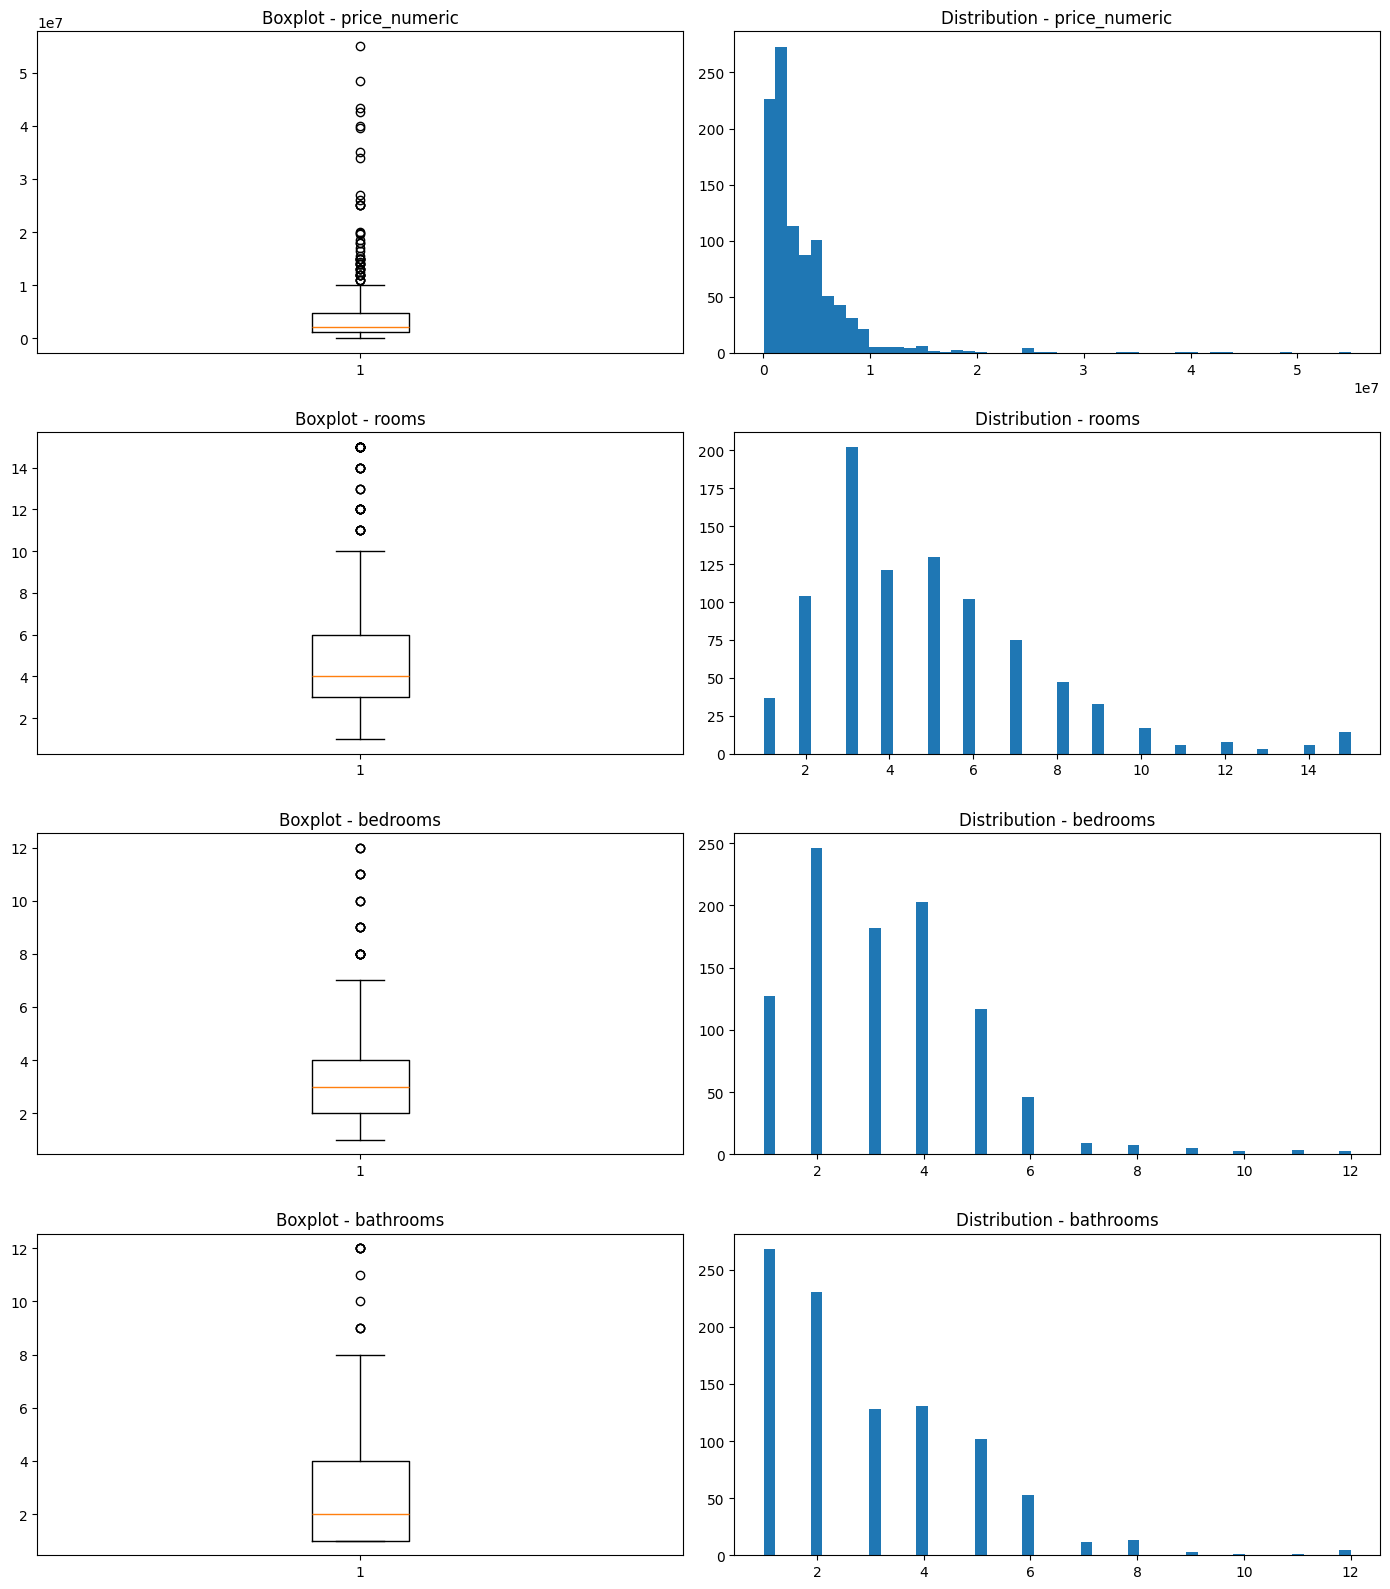

In [81]:
cols = ["price_numeric", "rooms", "bedrooms", "bathrooms"]

fig, axes = plt.subplots(len(cols), 2, figsize=(14, 4*len(cols)))

for i, col in enumerate(cols):
    axes[i, 0].boxplot(df[col].dropna())
    axes[i, 0].set_title(f"Boxplot - {col}")
    
    axes[i, 1].hist(df[col].dropna(), bins=50)
    axes[i, 1].set_title(f"Distribution - {col}")

plt.tight_layout()
plt.show()

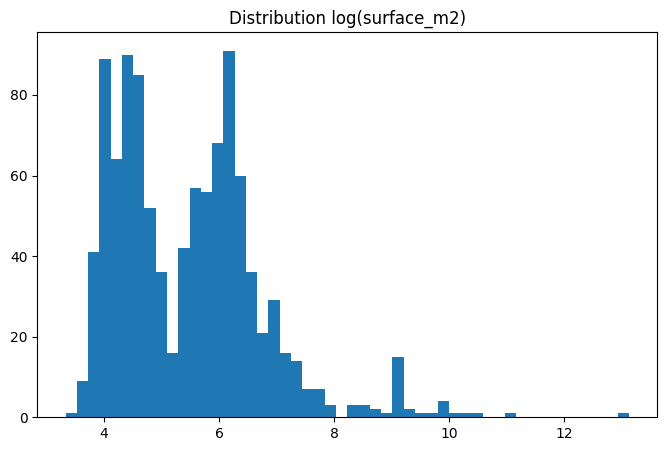

In [82]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["surface_m2"]), bins=50)
plt.title("Distribution log(surface_m2)")
plt.show()

In [83]:
df.columns

Index(['title', 'transaction_type', 'city', 'quartier', 'price_raw',
       'price_numeric', 'surface_raw', 'surface_m2', 'rooms', 'bedrooms',
       'bathrooms', 'description', 'property_type', 'surface_text',
       'surface_from_text', 'surface_clean', 'log_surface', 'log_price',
       'etat_bien', 'age_bien'],
      dtype='object')

### Floor, dataset final et correction des prix

In [84]:
# ===== Dataset final : les 9 colonnes demandees (+ Loc_Type derive) =====
df_model = pd.DataFrame({
    "Type":          df["property_type"],
    "Localisation":  df["quartier"],
    "Area":          df["surface_clean"],     # surface avec corrections manuelles
    "Rooms":         df["rooms"],
    "Bedrooms":      df["bedrooms"],
    "Bathrooms":     df["bathrooms"],
    "Current_state": df["etat_bien"],
    "Age":           df["age_bien"],
    "Price":         df["price_numeric"],
})

# valeurs impossibles -> "manquantes" (aucune ligne supprimee)
df_model.loc[df_model["Area"] < 15, "Area"] = np.nan

cat_cols = ["Type", "Localisation", "Current_state", "Age"]
df_model[cat_cols] = df_model[cat_cols].fillna("inconnu").astype(str)
df_model["Loc_Type"] = df_model["Localisation"] + "|" + df_model["Type"]

feat_cols = ["Type", "Localisation", "Area", "Rooms", "Bedrooms", "Bathrooms",
             "Current_state", "Age", "Loc_Type"]
labeled = df_model["Price"].notna()
X_all = df_model[feat_cols]

print(df_model["Type"].value_counts().to_dict())
print(df_model.shape, "| avec prix :", labeled.sum(), "| sans prix :", (~labeled).sum())
df_model.isna().sum()

{'Villa': 561, 'Appartement': 471}
(1032, 10) | avec prix : 994 | sans prix : 38


Type               0
Localisation       0
Area               5
Rooms            127
Bedrooms          79
Bathrooms         85
Current_state      0
Age                0
Price             38
Loc_Type           0
dtype: int64

In [85]:
import re, math
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, TargetEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 150)

In [86]:
cat_ohe = ["Type", "Localisation", "Current_state", "Age"]
num_plain = ["Rooms", "Bedrooms", "Bathrooms"]

def make_prep(scale=False):
    imp = lambda: SimpleImputer(strategy="median", add_indicator=True)
    area_steps = [("imp", imp()), ("log", FunctionTransformer(np.log1p))]   # Area : imputation puis log
    plain_steps = [("imp", imp())]
    if scale:
        area_steps.append(("sc", StandardScaler()))
        plain_steps.append(("sc", StandardScaler()))
    return ColumnTransformer([
        ("area", Pipeline(area_steps), ["Area"]),
        ("num", Pipeline(plain_steps), num_plain),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False), cat_ohe),
        ("te", TargetEncoder(target_type="continuous", smooth="auto", random_state=42), ["Loc_Type"]),
    ])

models_grids = {
    "Ridge": {
        "model": Pipeline([("prep", make_prep(scale=True)), ("m", Ridge())]),
        "params": {"m__alpha": [0.1, 1, 3, 10, 30]},
    },
    "Random Forest": {
        "model": Pipeline([("prep", make_prep()), ("m", RandomForestRegressor(random_state=42, n_jobs=-1))]),
        "params": {"m__n_estimators": [300, 600], "m__max_depth": [None, 12, 20],
                   "m__min_samples_leaf": [1, 2, 3], "m__max_features": [0.5, 0.8, 1.0]},
    },
    "Gradient Boosting": {
        "model": Pipeline([("prep", make_prep()), ("m", GradientBoostingRegressor(random_state=42))]),
        "params": {"m__n_estimators": [300, 600], "m__learning_rate": [0.03, 0.05, 0.1],
                   "m__max_depth": [3, 4, 5], "m__subsample": [0.7, 0.9, 1.0]},
    },
    "XGBoost": {
        "model": Pipeline([("prep", make_prep()), ("m", XGBRegressor(random_state=42, n_jobs=-1))]),
        "params": {"m__n_estimators": [300, 600], "m__learning_rate": [0.03, 0.05, 0.1],
                   "m__max_depth": [3, 4, 6], "m__subsample": [0.7, 0.9],
                   "m__colsample_bytree": [0.7, 0.9], "m__min_child_weight": [1, 3]},
    },
    "CatBoost": {
        "model": Pipeline([("prep", make_prep()), ("m", CatBoostRegressor(verbose=0, random_seed=42, allow_writing_files=False))]),
        "params": {"m__iterations": [500, 1000], "m__learning_rate": [0.03, 0.05, 0.1],
                   "m__depth": [4, 6, 8], "m__l2_leaf_reg": [1, 3, 5]},
    },
}

def evaluer(nom, model, Xtr, Xte, ytr, yte, extra=None):
    p_tr, p_te = model.predict(Xtr), model.predict(Xte)
    y_real, p_real = np.expm1(yte), np.expm1(p_te)
    row = {
        "Modèle": nom,
        "R2 Train (log)": round(r2_score(ytr, p_tr), 4),
        "R2 Test (log)":  round(r2_score(yte, p_te), 4),
        "R2 Test (DH)":   round(r2_score(y_real, p_real), 4),
        "MAE (DH)":       round(mean_absolute_error(y_real, p_real)),
        "MAPE median %":  round(float(np.median(np.abs(y_real - p_real) / y_real) * 100), 1),
    }
    if extra: row["Meilleurs paramètres"] = extra
    return row

In [87]:
# ===== Correction des prix : certaines annonces sont en EUROS mais affichees "DH" =====
EUR_RATE = 10.8                    # 1 EUR ~ 10.8 DH
CORRIGER_HEURISTIQUE = True        # False = on corrige seulement les annonces qui disent "euros" dans le texte

# 1) prix ecrit en euros dans le texte, egal (a 10% pres) au price_numeric
txt_all = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower()

def prix_euro_texte(t):
    m = re.search(r"(\d{1,3}(?:[\s.,]\d{3})+|\d{5,})\s*(?:€|euros?|eur\b)", t)
    if not m:
        return np.nan
    return float(re.sub(r"[\s.,]", "", m.group(1)))

df["eur_txt"] = txt_all.apply(prix_euro_texte)
df["is_eur"] = df["eur_txt"].notna() & (df["eur_txt"] / df["price_numeric"]).between(0.9, 1.1)
print("Annonces en euros (texte explicite) :", int(df["is_eur"].sum()))

# 2) annonces suspectes : prediction out-of-fold 4 a 20 fois plus grande que le prix affiche
X_l = X_all[labeled]
y_l = np.log1p(df_model.loc[labeled, "Price"])
baseline = Pipeline([("prep", make_prep()),
                     ("m", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                     max_depth=4, subsample=0.8, random_state=42))])
oof = np.expm1(cross_val_predict(baseline, X_l, y_l, cv=KFold(5, shuffle=True, random_state=0)))

P = df_model.loc[labeled, "Price"]
ratio = pd.Series(oof, index=P.index) / P
pm2 = P * EUR_RATE / df_model.loc[labeled, "Area"]
plausible = np.where(df_model.loc[labeled, "Type"] == "Appartement",
                     pm2.between(8000, 45000) | pm2.isna(),
                     (P * EUR_RATE) < 20_000_000)
suspect = ratio.between(4, 20) & plausible

# 3) application (les lignes restent, le prix d'origine est conserve dans Price_orig)
df_model["Price_orig"] = df_model["Price"]
df_model["is_eur"] = df["is_eur"].reindex(df_model.index).fillna(False).astype(bool)
df_model["Price_corrige"] = df_model["is_eur"]
if CORRIGER_HEURISTIQUE:
    df_model.loc[suspect[suspect].index, "Price_corrige"] = True

df_model.loc[df_model["Price_corrige"], "Price"] = df_model.loc[df_model["Price_corrige"], "Price_orig"] * EUR_RATE
print("Prix corriges :", int(df_model["Price_corrige"].sum()), "sur", int(labeled.sum()),
      "| dont texte euro :", int(df_model["is_eur"].sum()))

# verif visuelle : regarde ces lignes !
df_model[df_model["Price_corrige"]][["Type", "Localisation", "Area", "Price_orig", "Price"]].head(15)

Annonces en euros (texte explicite) : 2
Prix corriges : 69 sur 994 | dont texte euro : 2


,Type,Localisation,Area,Price_orig,Price
26,Villa,Autre / Centre,938.0,140000.0,1512000.0
27,Villa,Route de Fès,260.0,250000.0,2700000.0
28,Villa,Route de Fès,140.0,260000.0,2808000.0
29,Villa,Palmeraie,384.0,290000.0,3132000.0
30,Villa,Palmeraie,423.0,310000.0,3348000.0
31,Villa,Autre / Centre,264.0,320000.0,3456000.0
32,Villa,Palmeraie,453.0,330000.0,3564000.0
33,Villa,Route de Casablanca,266.0,350000.0,3780000.0
35,Villa,Route de Fès,720.0,375000.0,4050000.0
36,Villa,Amelkis,200.0,380000.0,4104000.0


### Nettoyage cible : terrains, euros, loyers, Vaneau

In [88]:
# ===== Nettoyage cible des prix / types (AUCUNE ligne supprimee) =====

# (a) annonces de TERRAIN classees "Villa" -> flag Is_terrain (aucune ligne supprimee)
t_low = df["title"].fillna("").str.lower()
is_terrain = t_low.str.contains(
    r"^\s*(?:vente\s+(?:de\s+|d')?)?(?:beau\s+|grand\s+)?terrain\b|\bterrain\s+(?:nu|constructible|titr|agricole|en milkia|à bâtir|a batir|à vendre|a vendre)",
    regex=True).reindex(df_model.index).fillna(False)
df_model["Is_terrain"] = is_terrain      # Type reste Villa/Appartement ; ces annonces sont exclues de l'entrainement
print("Annonces de terrain (exclues de l'entrainement) :", int(is_terrain.sum()))
display(df.loc[is_terrain[is_terrain].index, "title"].str[:80].head(12))

# (b) appartements en euros SANS mention dans le texte : prix/m2 impossible en DH mais normal x 10.8
pm2 = df_model["Price"] / df_model["Area"]
apt = df_model["Type"].eq("Appartement") & df_model["Price"].notna() & ~df_model["Price_corrige"]
regle_eur = apt & (pm2 < 4500) & (pm2 * EUR_RATE).between(9000, 45000)
df_model.loc[regle_eur, "Price"] = df_model.loc[regle_eur, "Price"] * EUR_RATE
df_model.loc[regle_eur, "Price_corrige"] = True
print("Appartements corriges (regle prix/m2) :", int(regle_eur.sum()))

# (c) prix encore impossibles -> traites comme "Prix à consulter" (la ligne reste, on PREDIT son prix)
pm2 = df_model["Price"] / df_model["Area"]
apt_bad = df_model["Type"].eq("Appartement") & ((pm2 < 4500) | (pm2 > 45000))
villa_bad = df_model["Type"].eq("Villa") & ~df_model["Is_terrain"] & (df_model["Price"] < 300_000)
suspect_final = (apt_bad | villa_bad) & df_model["Price"].notna()
df_model["Price_suspect"] = suspect_final
print("Prix suspects mis en 'a predire' :", int(suspect_final.sum()))
display(df_model.loc[suspect_final, ["Type", "Localisation", "Area", "Price_orig"]].head(15))
df_model.loc[suspect_final, "Price"] = np.nan      # Price_orig garde la valeur d'origine

# (d) reconstruire les variables utilisees par le split
df_model["Loc_Type"] = df_model["Localisation"] + "|" + df_model["Type"]
labeled = df_model["Price"].notna() & ~df_model["Is_terrain"]
X_all = df_model[feat_cols]
print("Avec prix :", int(labeled.sum()), "| a predire :", int((~labeled).sum()), "| lignes totales :", len(df_model))


Annonces de terrain (exclues de l'entrainement) : 52


1                                             Terrain Pré autorisé GH2
4                                  Terrain 1180m en 2 accès différents
18            Vente de terrain note pour agricole ou villa par hectare
76         Vente de terrain à Route de l'Ourika. Surface totale 250 m²
86            Vente terrain à Route de l'Ourika. Surface totale 300 m²
88             Terrain nu Villa 1 Ha 5 KM De Marrakech Vue sur l’Atlas
91                            Terrain Constructible viabilisé à Vendre
94                                 Terrain à vendre pour villa jumelée
99      Beau terrain à la vente à Route de l'Ourika. Surface totale...
100                   Terrain en milkia autorisé pour villa plain pied
101    Terrain 1000 m² idéal villa – face Aqua Park, 18 km Marrakec...
103            Très beau terrain titré de 2 hectares 20km de Marrakech
Name: title, dtype: object

Appartements corriges (regle prix/m2) : 6
Prix suspects mis en 'a predire' : 13


,Type,Localisation,Area,Price_orig
22,Villa,Route de Tahanaout,257.0,26000.0
23,Villa,Autre / Centre,500.0,35000.0
24,Villa,Hivernage,719.0,42000.0
25,Villa,Route de Tahanaout,600.0,50000.0
577,Appartement,Route de Casablanca,100.0,11000.0
578,Appartement,Guéliz,86.0,12500.0
579,Appartement,Autre / Centre,5073.0,13500.0
580,Appartement,Prestigia,85.0,14500.0
581,Appartement,Guéliz,61.0,18000.0
582,Appartement,Guéliz,61.0,18000.0


Avec prix : 933 | a predire : 99 | lignes totales : 1032


In [89]:
# ===== Agence Vaneau Maroc : prix/m2 ~6-8x plus bas que le reste -> prix en EUROS (hypothese) =====
desc_all = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower()
df["vaneau"] = desc_all.str.contains("vaneau")
print("Annonces Vaneau :", int(df["vaneau"].sum()))

CORRIGER_VANEAU = True
if CORRIGER_VANEAU:
    m = (df["vaneau"].reindex(df_model.index).fillna(False)
         & ~df_model["Price_corrige"]
         & df_model["Price_orig"].notna()
         & ~df_model["Is_terrain"])
    df_model.loc[m, "Price"] = df_model.loc[m, "Price_orig"] * EUR_RATE
    df_model.loc[m, "Price_corrige"] = True
    df_model.loc[m, "Price_suspect"] = False
    print("Vaneau corriges :", int(m.sum()))

labeled = df_model["Price"].notna() & ~df_model["Is_terrain"]
X_all = df_model[feat_cols]
print("Avec prix :", int(labeled.sum()), "| a predire :", int((~labeled).sum()), "| lignes totales :", len(df_model))

# verification : prix/m2 median (doit etre proche des autres annonces)
d = df_model.join(df["vaneau"])
d["pm2"] = d["Price"] / d["Area"]
d[~d["Is_terrain"]].groupby(["Type", "vaneau"])["pm2"].agg(["count", "median"]).round(0)

Annonces Vaneau : 20
Vaneau corriges : 12
Avec prix : 933 | a predire : 99 | lignes totales : 1032


count   median
Type        vaneau                
Appartement False     442  19047.0
            True        2  24741.0
Villa       False     468  12325.0
            True       16  20276.0

### Remplissage des valeurs manquantes (features)

In [90]:
# ===== Remplissage des valeurs manquantes (SANS utiliser le prix => pas de fuite) =====
cols_n = ["Rooms", "Bedrooms", "Bathrooms", "Area"]
print("NaN avant :", df_model[cols_n].isna().sum().to_dict())

# 1) extraction depuis le titre / la description
txt = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower()
patterns = {
    "Bedrooms":  r"(\d+)\s*(?:chambres?|chbres?|chs?\b|suites?|bedrooms?)",
    "Rooms":     r"(\d+)\s*(?:pi[eè]ces?|rooms?)",
    "Bathrooms": r"(\d+)\s*(?:salles?\s*(?:de\s*)?(?:bains?|d'eau)|sdb|bathrooms?)",
}
for col, pat in patterns.items():
    ext = pd.to_numeric(txt.str.extract(pat)[0], errors="coerce")
    df_model[col] = df_model[col].fillna(ext)

# 2) relation Rooms ~ Bedrooms (ecart median calcule sur les lignes completes)
diff = (df_model["Rooms"] - df_model["Bedrooms"]).median()
m = df_model["Rooms"].isna() & df_model["Bedrooms"].notna()
df_model.loc[m, "Rooms"] = df_model.loc[m, "Bedrooms"] + diff
m = df_model["Bedrooms"].isna() & df_model["Rooms"].notna()
df_model.loc[m, "Bedrooms"] = (df_model.loc[m, "Rooms"] - diff).clip(lower=1)

# 3) mediane du groupe le plus proche (Type+Localisation, puis Type, puis global)
df_model["Bathrooms"] = df_model["Bathrooms"].fillna(
    df_model.groupby(["Type", "Bedrooms"])["Bathrooms"].transform("median"))
for col in cols_n:
    df_model[col] = df_model[col].fillna(df_model.groupby(["Type", "Localisation"])[col].transform("median"))
    df_model[col] = df_model[col].fillna(df_model.groupby("Type")[col].transform("median"))
    df_model[col] = df_model[col].fillna(df_model[col].median())

# valeurs entieres et bornees
for col, cap in [("Rooms", 15), ("Bedrooms", 12), ("Bathrooms", 12)]:
    df_model[col] = df_model[col].round().clip(lower=1, upper=cap)

X_all = df_model[feat_cols]
print("NaN apres :", df_model[feat_cols].isna().sum().sum(), "(features) |",
      "Price NaN (a predire) :", int(df_model["Price"].isna().sum()))
df_model[cols_n].describe().round(1)

NaN avant : {'Rooms': 127, 'Bedrooms': 79, 'Bathrooms': 85, 'Area': 5}
NaN apres : 0 (features) | Price NaN (a predire) : 51


,Rooms,Bedrooms,Bathrooms,Area
count,1032.0,1032.0,1032.0,1032.0
mean,4.9,3.3,3.0,1401.3
std,2.7,1.7,1.9,16079.9
min,1.0,1.0,1.0,27.0
25%,3.0,2.0,1.0,83.0
50%,5.0,3.0,3.0,236.0
75%,6.0,4.0,4.0,500.0
max,15.0,12.0,12.0,504870.0


### Current_state et Age : plus de valeurs 'inconnu'

In [91]:
# ===== Remplacer "non spécifié" / "inconnu" par de vraies categories =====
from datetime import datetime
ANNEE = datetime.now().year
txt = (df["title"].fillna("") + " " + df["description"].fillna("")).str.lower().reindex(df_model.index)
print("Avant :", df_model["Current_state"].value_counts().to_dict(), df_model["Age"].value_counts().to_dict())

# --- 1) Current_state : plus de mots-cles (l'ordre compte : "à rénover" avant "rénové")
etat_rules = [
    ("à rénover", r"à rénover|a renover|à rafra[iî]chir|travaux à pr[ée]voir|vna\b"),
    ("neuf",      r"\bneuf\b|neuve\b|jamais habit|nouvelle construction|programme neuf|livraison|cl[ée]s en main"),
    ("bon état",  r"bon [ée]tat|excellent [ée]tat|parfait [ée]tat|r[ée]nov[ée]|refait|bien entretenu|habitable|impeccable|r[ée]cent"),
]
m = df_model["Current_state"].eq("non spécifié")
for label, pat in etat_rules:
    hit = m & txt.str.contains(pat, regex=True)
    df_model.loc[hit, "Current_state"] = label
    m = m & ~hit

# --- 2) Age : annee de construction, puis coherence avec l'etat
def age_depuis_annee(t):
    r = re.search(r"(?:construit[e]?|construction|b[âa]ti[e]?|ann[ée]e)\s*(?:de\s*construction\s*)?(?:en|de|:)?\s*((?:19|20)\d{2})", t)
    return ANNEE - int(r.group(1)) if r else np.nan

def bucket(a):
    if pd.isna(a): return np.nan
    return "0-5 ans" if a <= 5 else ("5-10 ans" if a <= 10 else "+10 ans")

m = df_model["Age"].eq("inconnu")
df_model.loc[m, "Age"] = txt[m].apply(age_depuis_annee).apply(bucket).fillna("inconnu")

m = df_model["Age"].eq("inconnu")
df_model.loc[m & df_model["Current_state"].eq("neuf"), "Age"] = "0-5 ans"
df_model.loc[m & df_model["Current_state"].eq("à rénover"), "Age"] = "+10 ans"
df_model.loc[m & txt.str.contains(r"\bancien(?:ne)?\b|vieille", regex=True), "Age"] = "+10 ans"

# --- 3) le reste : valeur neutre ("bon état" / "+10 ans"). Le mode du groupe serait biaise :
#        les vendeurs ecrivent "neuf" quand c'est neuf, donc les annonces silencieuses sont plutot anciennes
STRATEGIE = "constante"    # "constante" (conseille) ou "groupe" (mode du Type+Localisation)

def remplir_mode(col, bad, defaut):
    miss = df_model[col].eq(bad)
    if STRATEGIE == "constante":
        df_model.loc[miss, col] = defaut; return
    known = df_model[~miss]
    if known.empty:
        print(f"  (!) {col}: aucune valeur connue -> '{defaut}' partout"); df_model.loc[miss, col] = defaut; return
    mode = lambda s: s.mode().iloc[0]
    g1 = known.groupby(["Type", "Localisation"])[col].agg(mode)
    g2 = known.groupby("Type")[col].agg(mode)
    glob = mode(known[col])
    for i in df_model.index[miss]:
        t, l = df_model.at[i, "Type"], df_model.at[i, "Localisation"]
        df_model.at[i, col] = g1.get((t, l), g2.get(t, glob))

remplir_mode("Current_state", "non spécifié", "bon état")
remplir_mode("Age", "inconnu", "+10 ans")

assert not df_model[["Current_state", "Age"]].isin(["non spécifié", "inconnu"]).any().any()
X_all = df_model[feat_cols]

print("Apres :", df_model["Current_state"].value_counts().to_dict(), df_model["Age"].value_counts().to_dict())


Avant : {'non spécifié': 884, 'neuf': 90, 'bon état': 33, 'à rénover': 25} {'inconnu': 986, '0-5 ans': 21, '5-10 ans': 21, '+10 ans': 4}
Apres : {'bon état': 862, 'neuf': 144, 'à rénover': 26} {'+10 ans': 845, '0-5 ans': 165, '5-10 ans': 22}


In [107]:
final_cols = ["Type", "Localisation", "Area", "Rooms", "Bedrooms", "Bathrooms", "Current_state", "Age"]

df_csv = df_model[final_cols].copy()
df_csv["Price"] = df_model["Price_final"]   # prix reel (corrige si euro) ou prix predit

# terrains sans prix : mediane du groupe, pour ne laisser aucune valeur nulle
df_csv["Price"] = df_csv["Price"].fillna(df_csv.groupby(["Type", "Localisation"])["Price"].transform("median"))
df_csv["Price"] = df_csv["Price"].fillna(df_csv["Price"].median())

# entiers propres
for c in ["Rooms", "Bedrooms", "Bathrooms"]:
    df_csv[c] = df_csv[c].astype(int)
df_csv["Area"] = df_csv["Area"].round(0).astype(int)
df_csv["Price"] = df_csv["Price"].round(0).astype(int)

# sauvegarde
import os
df_csv.to_csv("marrakech_clean.csv", index=False, encoding="utf-8-sig")

print("Fichier :", os.path.abspath("marrakech_clean.csv"))
print(df_csv.shape, "| valeurs nulles :", int(df_csv.isna().sum().sum()))
df_csv.head()

Fichier : c:\Users\ennak\OneDrive\Desktop\mubawab\marrakech\marrakech_clean.csv
(1032, 9) | valeurs nulles : 0


,Type,Localisation,Area,Rooms,Bedrooms,Bathrooms,Current_state,Age,Price
0,Villa,Autre / Centre,340,6,4,4,neuf,0-5 ans,4469000
1,Villa,Route de l'Ourika,26724,6,4,4,bon état,+10 ans,4850000
2,Villa,Route d'Amizmiz,20000,14,9,8,bon état,+10 ans,23412000
3,Villa,Route de l'Ourika,20000,9,6,7,bon état,+10 ans,15831000
4,Villa,Targa,1177,6,4,4,bon état,+10 ans,4950000


In [92]:
# ===== Split (avec les prix corriges) =====
X = X_all[labeled]
y = np.log1p(df_model.loc[labeled, "Price"])      # TARGET EN LOG

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Winsorisation de la target d'entrainement (on CLIPPE, on ne supprime rien)
lo, hi = y_train.quantile([0.01, 0.99])
y_train_w = y_train.clip(lo, hi)
print(X_train.shape, X_test.shape)

(746, 9) (187, 9)


<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">4- Modélisation</h2>
</div>

In [93]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results, best_models = [], {}

for name, cfg in models_grids.items():
    print(f"⏳ {name} ...")
    search = RandomizedSearchCV(cfg["model"], cfg["params"], n_iter=15, cv=kf,
                                scoring="r2", n_jobs=-1, random_state=42)
    search.fit(X_train, y_train_w)                    # entraine sur y winsorise
    best_models[name] = search.best_estimator_
    results.append(evaluer(name, search.best_estimator_, X_train, X_test, y_train, y_test,
                           str(search.best_params_)))   # evalue sur les VRAIS prix

tableau = pd.DataFrame(results).sort_values("R2 Test (log)", ascending=False).reset_index(drop=True)
tableau

⏳ Ridge ...


c:\Users\ennak\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 5 is smaller than n_iter=15. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


⏳ Random Forest ...
⏳ Gradient Boosting ...
⏳ XGBoost ...
⏳ CatBoost ...


,Modèle,R2 Train (log),R2 Test (log),R2 Test (DH),MAE (DH),MAPE median %,Meilleurs paramètres
0,Random Forest,0.8250,0.6724,0.4861,1463845,17.0,"{'m__n_estimators': 600, 'm__min_samples_leaf': 3, 'm__max_features': 0.5, 'm__max_depth': None}"
1,Ridge,0.7148,0.6615,0.4537,1529240,18.6,{'m__alpha': 3}
2,XGBoost,0.8358,0.6537,0.1993,1659727,19.2,"{'m__subsample': 0.9, 'm__n_estimators': 300, 'm__min_child_weight': 1, 'm__max_depth': 3, 'm__learning_rate': 0.05, 'm__colsample_bytree': 0.9}"
3,CatBoost,0.7866,0.6474,0.4254,1598676,19.3,"{'m__learning_rate': 0.03, 'm__l2_leaf_reg': 5, 'm__iterations': 500, 'm__depth': 4}"
4,Gradient Boosting,0.8501,0.6392,0.0545,1767309,18.8,"{'m__subsample': 1.0, 'm__n_estimators': 300, 'm__max_depth': 4, 'm__learning_rate': 0.03}"


In [94]:
def estimateur_stack(nom):
    est = clone(best_models[nom])            # copie non entrainee, memes hyperparametres
    if nom == "CatBoost":                    # bug d'encodage Windows (chemin avec accent)
        est.set_params(m__allow_writing_files=False)
    return est

top3 = tableau["Modèle"].head(3).tolist()
stack = StackingRegressor(
    estimators=[(n, estimateur_stack(n)) for n in top3],
    final_estimator=Ridge(alpha=1.0), cv=5, n_jobs=1
)
stack.fit(X_train, y_train_w)

final = pd.DataFrame([evaluer("Stacking " + "+".join(top3), stack, X_train, X_test, y_train, y_test)])
final

,Modèle,R2 Train (log),R2 Test (log),R2 Test (DH),MAE (DH),MAPE median %
0,Stacking Random Forest+Ridge+XGBoost,0.7906,0.6777,0.5179,1455374,17.5


In [95]:
# R2 en cross-validation sur toutes les annonces avec prix (plus fiable qu'un seul split)
best_name = tableau.loc[0, "Modèle"]
cv_scores = cross_val_score(best_models[best_name], X, y, cv=KFold(5, shuffle=True, random_state=0), scoring="r2")
print(f"{best_name} | R2 CV (log) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Random Forest | R2 CV (log) : 0.692 ± 0.041


In [96]:
# ===== Prediction des annonces SANS prix (aucune ligne supprimee) =====
modele_final = stack
modele_final.fit(X, y.clip(lo, hi))               # re-entraine sur toutes les annonces avec prix

df_model["Price_pred"] = np.expm1(modele_final.predict(X_all)).round(-3)
df_model.loc[df_model["Is_terrain"], "Price_pred"] = np.nan   # pas de prediction pour les terrains
df_model["Price_final"] = df_model["Price"].fillna(df_model["Price_pred"])

print(df_model.shape, "| NaN Price_final :", df_model["Price_final"].isna().sum())
df_model.loc[~labeled, ["Type", "Localisation", "Area", "Bedrooms", "Price_pred"]].head(10)

(1032, 17) | NaN Price_final : 4


,Type,Localisation,Area,Bedrooms,Price_pred
0,Villa,Autre / Centre,340.0,4.0,4469000.0
1,Villa,Route de l'Ourika,26724.0,4.0,NaN
2,Villa,Route d'Amizmiz,20000.0,9.0,23412000.0
3,Villa,Route de l'Ourika,20000.0,6.0,15831000.0
4,Villa,Targa,1177.0,4.0,NaN
5,Villa,Autre / Centre,500.0,5.0,5717000.0
6,Villa,Guéliz,20000.0,1.0,8845000.0
7,Villa,Amelkis,1200.0,8.0,10197000.0
8,Villa,Route de Tahanaout,1000.0,8.0,7300000.0
9,Villa,Autre / Centre,424.0,5.0,5546000.0


### Diagnostic

In [97]:
# ===== Diagnostic des erreurs (sur le jeu de test) =====
best = best_models[best_name]
res = X_test.copy()
res["prix_reel"] = np.expm1(y_test)
res["prix_pred"] = np.expm1(best.predict(X_test))
res["err_%"] = ((res["prix_pred"] / res["prix_reel"] - 1) * 100).round(0)

for t, g in res.groupby("Type"):
    print(t, len(g), "R2 log:", round(r2_score(np.log1p(g["prix_reel"]), np.log1p(g["prix_pred"])), 3))

d = df_model[labeled].copy()
d["prix_m2"] = d["Price"] / d["Area"]
display(d.groupby("Type")["prix_m2"].describe(percentiles=[.01, .05, .5, .95, .99]).round(0))

top = res.reindex(res["err_%"].abs().sort_values(ascending=False).index).head(20)
top = top.join(df_model[["Price_orig", "Price_corrige"]])
top["prix_m2"] = (top["prix_reel"] / top["Area"]).round(0)
top["title"] = df.loc[top.index, "title"].str[:70]
top[["Type", "Localisation", "Area", "Bedrooms", "Price_orig", "Price_corrige",
     "prix_reel", "prix_pred", "err_%", "prix_m2", "title"]]

Appartement 88 R2 log: 0.675
Villa 99 R2 log: 0.064


,count,mean,std,min,1%,5%,50%,95%,99%,max
Type,,,,,,,,,,
Appartement,446.0,19177.0,6863.0,4554.0,6492.0,8000.0,19093.0,31053.0,37356.0,43200.0
Villa,487.0,13256.0,8217.0,79.0,353.0,1604.0,12500.0,28015.0,38725.0,62500.0


,Type,Localisation,Area,Bedrooms,Price_orig,Price_corrige,prix_reel,prix_pred,err_%,prix_m2,title
75,Villa,Route de Fès,1085.0,10.0,950000.0,False,950000.0,1.863207e+07,1861.0,876.0,Domaine champêtre d'exception 3 villas
57,Villa,Route de l'Ourika,460.0,8.0,650000.0,False,650000.0,1.053623e+07,1521.0,1413.0,"Villa avec VNA route de l'Ourika, vue Atlas"
65,Villa,Palmeraie,570.0,4.0,830000.0,False,830000.0,4.453940e+06,437.0,1456.0,Villa Deluxe Premium 4 suites & piscine privée VNA
105,Villa,Autre / Centre,4200.0,2.0,1500000.0,False,1500000.0,6.544207e+06,336.0,357.0,Ferme avec Villa Plain Pied à Vendre à Ghmat – Route de L’Ou...
116,Villa,Amelkis,600.0,6.0,1750000.0,False,1750000.0,7.032164e+06,302.0,2917.0,Villa de Luxe avec 6 Suites sur le Golf d'Amelkis
611,Appartement,Autre / Centre,78.0,2.0,380000.0,False,380000.0,1.495531e+06,294.0,4872.0,Appartement à vendre
97,Villa,Autre / Centre,450.0,4.0,1350000.0,False,1350000.0,5.032826e+06,273.0,3000.0,"Propriété de charme avec VNA – Villa de standing sur 1,1 hec..."
615,Appartement,Autre / Centre,57.0,2.0,400000.0,False,400000.0,1.139502e+06,185.0,7018.0,Appartement rez-de-chaussée Doha portes de Marrakech
119,Villa,Autre / Centre,520.0,4.0,1800000.0,False,1800000.0,4.998429e+06,178.0,3462.0,Lot terrain villa plain pied 520m2
158,Villa,Route d'Amizmiz,560.0,8.0,2500000.0,False,2500000.0,6.765730e+06,171.0,4464.0,Vente villa de luxe à Route Amizmiz. Surface de 560 m². Meub...


### Verification finale : aucune valeur manquante

In [106]:
final_cols = ["Type", "Localisation", "Area", "Rooms", "Bedrooms", "Bathrooms", "Current_state", "Age"]
df_out = df_model[final_cols + ["Price_final"]].rename(columns={"Price_final": "Price"})
print(df_out.isna().sum())
df_out.head()

Type             0
Localisation     0
Area             0
Rooms            0
Bedrooms         0
Bathrooms        0
Current_state    0
Age              0
Price            4
dtype: int64


,Type,Localisation,Area,Rooms,Bedrooms,Bathrooms,Current_state,Age,Price
0,Villa,Autre / Centre,340.0,6.0,4.0,4.0,neuf,0-5 ans,4469000.0
1,Villa,Route de l'Ourika,26724.0,6.0,4.0,4.0,bon état,+10 ans,NaN
2,Villa,Route d'Amizmiz,20000.0,14.0,9.0,8.0,bon état,+10 ans,23412000.0
3,Villa,Route de l'Ourika,20000.0,9.0,6.0,7.0,bon état,+10 ans,15831000.0
4,Villa,Targa,1177.0,6.0,4.0,4.0,bon état,+10 ans,NaN


In [102]:
df_out["Type"].value_counts()

Type
Villa          561
Appartement    471
Name: count, dtype: int64

In [ ]:
df_out["Localisation"].value_counts()

Localisation
Autre / Centre         226
Guéliz                 216
Route de l'Ourika      101
Palmeraie               65
Targa                   64
Route d'Amizmiz         60
Route de Tahanaout      50
Route de Casablanca     45
M'hamid                 34
Route de Fès            33
Hivernage               27
Amelkis                 24
Prestigia               21
Agdal                   18
Route de Safi           16
Chrifia                 14
Ménara                  12
Médina                   6
Name: count, dtype: int64

In [105]:
df_out["Age"].value_counts()

Age
+10 ans     845
0-5 ans     165
5-10 ans     22
Name: count, dtype: int64